# ¿Cómo y dónde gasta el Estado chileno a través de Mercado Público, y dónde están las mejores oportunidades para un proveedor? #

In [1]:
#importamos librerias

import pandas as pd
import numpy as np

#Dado que los archivos tiene la misma estructura uso glob.

import glob


archivos = glob.glob('C:/Users/OAD/Documents/mercado-publico-eda/mercado-publico-eda/data/raw/*.csv')
df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)

C:\Users\OAD\AppData\Local\Temp\ipykernel_17464\3345982246.py:12: DtypeWarning: Columns (21,31,53,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)
C:\Users\OAD\AppData\Local\Temp\ipykernel_17464\3345982246.py:12: DtypeWarning: Columns (21,31,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)
C:\Users\OAD\AppData\Local\Temp\ipykernel_17464\3345982246.py:12: DtypeWarning: Columns (21,31,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)


In [2]:
#Borramos entradas duplicadas
print('Filas antes: ', len(df))
df = df.drop_duplicates(subset=['ID', 'IDItem'])
print('Filas despues: ', len(df))

Filas antes:  1124505
Filas despues:  1124505


*No existen entradas duplicadas en el dataset.*

In [3]:
df.shape #Comprobamos shape

(1124505, 78)

In [4]:
df.columns.tolist() #Chequeamos columnas.

['ID',
 'Codigo',
 'Link',
 'Nombre',
 'Descripcion/Obervaciones',
 'Tipo',
 'ProcedenciaOC',
 'EsTratoDirecto',
 'EsCompraAgil',
 'CodigoTipo',
 'CodigoAbreviadoTipoOC',
 'DescripcionTipoOC',
 'codigoEstado',
 'Estado',
 'codigoEstadoProveedor',
 'EstadoProveedor',
 'FechaCreacion',
 'FechaEnvio',
 'FechaSolicitudCancelacion',
 'fechaUltimaModificacion',
 'FechaAceptacion',
 'FechaCancelacion',
 'tieneItems',
 'PromedioCalificacion',
 'CantidadEvaluacion',
 'MontoTotalOC',
 'TipoMonedaOC',
 'MontoTotalOC_PesosChilenos',
 'Impuestos',
 'TipoImpuesto',
 'Descuentos',
 'Cargos',
 'TotalNetoOC',
 'CodigoUnidadCompra',
 'RutUnidadCompra',
 'UnidadCompra',
 'CodigoOrganismoPublico',
 'OrganismoPublico',
 'sector',
 'ActividadComprador',
 'CiudadUnidadCompra',
 'RegionUnidadCompra',
 'PaisUnidadCompra',
 'CodigoSucursal',
 'RutSucursal',
 'Sucursal',
 'CodigoProveedor',
 'NombreProveedor',
 'ActividadProveedor',
 'ComunaProveedor',
 'RegionProveedor',
 'PaisProveedor',
 'Financiamiento',
 'P

*Se consideran las columnas utiles para el analisis.*
*Se crea una nueva tabla con las columnas utiles para su posterior limpieza y validación*


In [5]:
cols = ['ID', 'OrganismoPublico', 'sector', 'FechaEnvio', 'MontoTotalOC_PesosChilenos', 'totalLineaNeto', 'NombreProveedor', 'Categoria', 'RubroN1']
df_limpieza = df[cols].copy()
df_limpieza.head() #Se verifica la creación de la nueva tabla.

,ID,OrganismoPublico,sector,FechaEnvio,MontoTotalOC_PesosChilenos,totalLineaNeto,NombreProveedor,Categoria,RubroN1
0,46636823,ILUSTRE MUNICIPALIDAD DE COLBUN,Municipalidades,2026-01-19,13447000,11300000,INVETMED,"Servicios agrícolas, pesqueros, forestales y r...","Servicios agrícolas, pesqueros, forestales y r..."
1,46824565,I MUNICIPALIDAD DE TEMUCO,Municipalidades,2026-01-29,"892,5",750,PEDRO ANDRÉS GAETE VILLEGAS,"Servicios basados en ingeniería, ciencias soci...","Servicios basados en ingeniería, ciencias soci..."
2,47646675,SERVICIO DE VIVIENDA Y URBANIZACION VII REGION,Obras Públicas,2026-01-30,"76924550,390625",2170,SOINTEC INGENIEROS CONSULTORES LTDA.,"Servicios profesionales, administrativos y con...","Servicios profesionales, administrativos y con..."
3,50874555,I MUNICIPALIDAD DE SALAMANCA,Municipalidades,2026-01-28,"6916399,9996",620000,MIGUEL ANGEL VILLARROEL ARAYA,"Artículos para estructuras, obras y construcci...","Artículos para estructuras, obras y construcci..."
4,50874555,I MUNICIPALIDAD DE SALAMANCA,Municipalidades,2026-01-28,"6916399,9996",2160000,MIGUEL ANGEL VILLARROEL ARAYA,"Artículos para estructuras, obras y construcci...","Artículos para estructuras, obras y construcci..."


*Se comprueba que el total de entradas sea el mismo que el total de IDs unicas*

In [6]:
print('IDs totales: ', len(df_limpieza))
print(f'IDs unicas:', df_limpieza['ID'].nunique())

IDs totales:  1124505
IDs unicas: 401077


*Se sospecha que cada entrada es un item y no una orden de compra ya que hay más entradas que IDs unicas*

In [7]:
print('IDs duplicadas: ', df_limpieza['ID'].duplicated().sum())
print('Entradas duplicadas: ', df_limpieza.duplicated().sum())

IDs duplicadas:  723428
Entradas duplicadas:  83552


*Se descartan las entradas duplicadas y se conservan las IDs duplicadas posteriores*

In [8]:
duplicados_pre = df_limpieza.duplicated().sum()
print(duplicados_pre) #Muestra duplicados pre-limpieza
df_limpieza = df_limpieza.drop_duplicates()
duplicados_post = df_limpieza.duplicated().sum()
print(duplicados_post) #Muestra duplicados post-limpieza


83552
0


*Aún quedan IDs unicas repetidas.
Se cuestiona si cada entrada es un item comprado o una orden de compra. Se investiga para verificar legitimidad del dataframe*

In [9]:
df.columns.tolist() #Chequeamos columnas nuevamente. #Existe IDTtem

['ID',
 'Codigo',
 'Link',
 'Nombre',
 'Descripcion/Obervaciones',
 'Tipo',
 'ProcedenciaOC',
 'EsTratoDirecto',
 'EsCompraAgil',
 'CodigoTipo',
 'CodigoAbreviadoTipoOC',
 'DescripcionTipoOC',
 'codigoEstado',
 'Estado',
 'codigoEstadoProveedor',
 'EstadoProveedor',
 'FechaCreacion',
 'FechaEnvio',
 'FechaSolicitudCancelacion',
 'fechaUltimaModificacion',
 'FechaAceptacion',
 'FechaCancelacion',
 'tieneItems',
 'PromedioCalificacion',
 'CantidadEvaluacion',
 'MontoTotalOC',
 'TipoMonedaOC',
 'MontoTotalOC_PesosChilenos',
 'Impuestos',
 'TipoImpuesto',
 'Descuentos',
 'Cargos',
 'TotalNetoOC',
 'CodigoUnidadCompra',
 'RutUnidadCompra',
 'UnidadCompra',
 'CodigoOrganismoPublico',
 'OrganismoPublico',
 'sector',
 'ActividadComprador',
 'CiudadUnidadCompra',
 'RegionUnidadCompra',
 'PaisUnidadCompra',
 'CodigoSucursal',
 'RutSucursal',
 'Sucursal',
 'CodigoProveedor',
 'NombreProveedor',
 'ActividadProveedor',
 'ComunaProveedor',
 'RegionProveedor',
 'PaisProveedor',
 'Financiamiento',
 'P

*El existir de 'IDItem' nos permite concluir que cada ID distinta es una OC distinta y no un item unico.
Sin embargo, esto significa que cada ID contiene el monto total y no el monto unico del item. Por lo que inflaria los resultados de trabajar con esta columna.*

*Se descartan las otras columnas con IDs repetidas dado que representarian montos totales repetidos al conservarlas.*

In [10]:
ids_duplicadas_pre = df_limpieza['ID'].duplicated().sum()
print('IDs duplicadas antes: ', ids_duplicadas_pre)
df_limpieza = df_limpieza.drop_duplicates(subset=['ID'])
ids_duplicadas_post = df_limpieza['ID'].duplicated().sum()
print('IDs duplicadas actuales: ', ids_duplicadas_post)



IDs duplicadas antes:  639876
IDs duplicadas actuales:  0


*Se concluye que trabajar con IDs unicas es lo optimo*

*Se comprueban nulos, dtypes y resumén.*

In [11]:
df_limpieza.isna().sum()

ID                                0
OrganismoPublico                  0
sector                        10752
FechaEnvio                        0
MontoTotalOC_PesosChilenos        0
totalLineaNeto                    3
NombreProveedor                   0
Categoria                     42708
RubroN1                       42708
dtype: int64

In [12]:
df_limpieza.dtypes #Se comprueban los dtypes.

ID                             int64
OrganismoPublico              object
sector                        object
FechaEnvio                    object
MontoTotalOC_PesosChilenos    object
totalLineaNeto                object
NombreProveedor               object
Categoria                     object
RubroN1                       object
dtype: object

In [13]:
df_limpieza.info() #Resumén

<class 'pandas.core.frame.DataFrame'>
Index: 401077 entries, 0 to 1124503
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   ID                          401077 non-null  int64 
 1   OrganismoPublico            401077 non-null  object
 2   sector                      390325 non-null  object
 3   FechaEnvio                  401077 non-null  object
 4   MontoTotalOC_PesosChilenos  401077 non-null  object
 5   totalLineaNeto              401074 non-null  object
 6   NombreProveedor             401077 non-null  object
 7   Categoria                   358369 non-null  object
 8   RubroN1                     358369 non-null  object
dtypes: int64(1), object(8)
memory usage: 30.6+ MB


*Se convierte la columna de fecha a su optimo dtype.*

In [14]:
df_limpieza['FechaEnvio'] = pd.to_datetime(df_limpieza['FechaEnvio'], errors='coerce')
df_limpieza.dtypes #Comprobación.

ID                                     int64
OrganismoPublico                      object
sector                                object
FechaEnvio                    datetime64[ns]
MontoTotalOC_PesosChilenos            object
totalLineaNeto                        object
NombreProveedor                       object
Categoria                             object
RubroN1                               object
dtype: object

*Se convierte la columna de monto (MontoTotalOC_PesosChilenos) a su optimo dtype.*

In [15]:

# df_limpieza['MontoTotalOC_PesosChilenos'] = df_limpieza['MontoTotalOC_PesosChilenos'].astype('Int64') #Error. La columna contiene floats

#La columna contiene decimales. Raro para ser un monto de dinero. Se comienza a sospechar que la columna es resultado de alguna formula.

# df_limpieza['MontoTotalOC_PesosChilenos'] = df_limpieza['MontoTotalOC_PesosChilenos'].astype(float) #Error. Se debe modificar la puntuación al estandar de Python.

df_limpieza['MontoTotalOC_PesosChilenos'] = (df_limpieza['MontoTotalOC_PesosChilenos']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float))
df_limpieza.dtypes #Comprobación.

ID                                     int64
OrganismoPublico                      object
sector                                object
FechaEnvio                    datetime64[ns]
MontoTotalOC_PesosChilenos           float64
totalLineaNeto                        object
NombreProveedor                       object
Categoria                             object
RubroN1                               object
dtype: object

*Se convierte la columna de monto (totalLineaNeto) a su optimo dtype.*

In [16]:
# df_limpieza['totalLineaNeto'] = df_limpieza['totalLineaNeto'].astype('Int64') #Error. Contiene floats.

#Mismo proceso que el anterior.

df_limpieza['totalLineaNeto'] = (df_limpieza['totalLineaNeto']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float))
df_limpieza.dtypes #Comprobación.

ID                                     int64
OrganismoPublico                      object
sector                                object
FechaEnvio                    datetime64[ns]
MontoTotalOC_PesosChilenos           float64
totalLineaNeto                       float64
NombreProveedor                       object
Categoria                             object
RubroN1                               object
dtype: object

*Se comprueba la proporción de nulos por columna*

In [17]:
df_porcentaje_nulos = (df_limpieza.isna().sum() / len(df_limpieza) * 100).round(2)
print(df_porcentaje_nulos)

ID                             0.00
OrganismoPublico               0.00
sector                         2.68
FechaEnvio                     0.00
MontoTotalOC_PesosChilenos     0.00
totalLineaNeto                 0.00
NombreProveedor                0.00
Categoria                     10.65
RubroN1                       10.65
dtype: float64


*Se inspeccionan los nulos de 'sector', 'Categoria' y 'RubroN1'.*

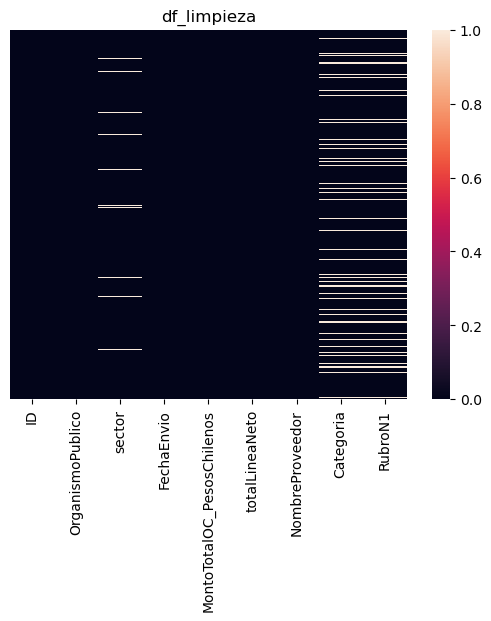

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

#Mapa de calor.
sns.heatmap(df_limpieza.isna(), cbar=True, yticklabels=False)
plt.title('df_limpieza')
plt.show()

#### *Se investiga que proveedor y organismo registra la mayor cantidad de nulos.* ####

In [19]:
sin_clasificacion = df_limpieza[
    df_limpieza['Categoria'].isna() |
    df_limpieza['RubroN1'].isna() |
    df_limpieza['sector'].isna()
]
print(f'Total filas con algún nulo: {len(sin_clasificacion)}')
print()
print('---Organismos con más clasificaciones nulas---')
print(sin_clasificacion['OrganismoPublico'].value_counts().head(20))
print()
print('---Proveedores con más clasificaciones nulas---')
print(sin_clasificacion['NombreProveedor'].value_counts().head(20))

Total filas con algún nulo: 52227

---Organismos con más clasificaciones nulas---
OrganismoPublico
DIRECCION GENERAL DE GENDARMERIA DE CHIL                      3285
DIRECCION DE LOGISTICA DE CARABINEROS                         2361
DIVISION LOGISTICA DEL EJERCITO                               2036
DIRECCION DE ABASTECIMIENTO DE LA ARMADA                      1708
HOSPITAL DOCTOR ERNESTO TORRES GALDAMES                       1175
UNIVERSIDAD DE CHILE                                          1141
SERVICIO NACIONAL DE REINSERCION SOCIAL JUVENIL                957
SERVICIO NACIONAL DE PREVENCIÓN Y RESPUESTA ANTE DESASTRES     868
SERVICIO DE SALUD ANTOFAGASTA HOSPITAL L                       717
SERVICIO DE SALUD ARICA HOSP DR JUAN NOE CREVANI               658
FUERZA AEREA DE CHILE COMANDO LOGISTICO                        627
SERVICIO NACIONAL DE SALUD HOSPITAL DE C                       606
MINISTERIO DE OBRAS PUBLICAS DIREC CION GRAL DE OO PP DCYF     598
Servicio Local de Educación Pú

*Se aprecia una gran cantidad de clasificaciones proporcionadas por organismos grandes como Gendarmeria de Chile, Carabineros de Chile, Ejercito de Chile y Dirección de abastecimiento de la armada. Se planteo la hipotesis que fue a proposito por motivos de confidencialidad, pero la lista de proveedores nos indica que son productos del dia a dia (En este caso: Gas licuado, tickets de vuelo, articulos de oficina, entre otros.) que no tienen como ser indexados en MercadoPublico.*

*Proporción de nulos por organismo.*

In [20]:
df_limpieza['sin_clasificacion'] = (
    df_limpieza['Categoria'].isna() |
    df_limpieza['RubroN1'].isna() |
    df_limpieza['sector'].isna()
)
perfil = df_limpieza.groupby('OrganismoPublico').agg(
    total=('sin_clasificacion', 'size'),
    nulos=('sin_clasificacion', 'sum'))
perfil['pct'] = (perfil['nulos'] / perfil['total'] * 100).round(1)

print(perfil[perfil['total'] >= 50].sort_values('pct', ascending=False).head(20).to_string()) #mostrar solo los más relevantes (mayor a 50)
df_limpieza.drop(columns='sin_clasificacion', inplace=True)

                                                                            total  nulos    pct
OrganismoPublico                                                                               
Servicio Local de Educación Pública Aysén                                     391    391  100.0
SERVICIO LOCAL DE EDUCACIÓN PÚBLICA SANTIAGO CENTRO                            65     65  100.0
CORPORACION DE DESARROLLO TERRITORIAL Y TURISMO DE LA REGION METROPOLITANA     95     95  100.0
CORPORACION DE DESARROLLO SOCIAL DE BUIN                                      157    157  100.0
Servicio Local de Educación Pública Punilla Cordillera                        567    567  100.0
CORPORACION CULTURAL MUNICIPAL DE LA COMUNA DE CHILLAN                         52     52  100.0
CORPORACION CULTURAL DE VITACURA                                              133    133  100.0
CORPORACION CULTURAL DE LA ILUSTRE MUNICIPALIDAD DE VALDIVIA                   53     53  100.0
SERVICIO LOCAL DE EDUCACIÓN PÚBLICA SANT

*No se descarta que FFAA sean protagonistas en la entrega de nulos. En cambio, se destacan organismos educativos con totalidad de OCs con clasificaciones nulas. Aún asi, se calcula proporción de nulos del top 4 de nulos de clasificación.*

In [21]:
seguridad = ['DIRECCION GENERAL DE GENDARMERIA DE CHIL',
             'DIRECCION DE LOGISTICA DE CARABINEROS',
             'DIVISION LOGISTICA DEL EJERCITO',
             'DIRECCION DE ABASTECIMIENTO DE LA ARMADA']
print('Top 4 con mayor nulos en proporción')
print(perfil.loc[seguridad].to_string())

Top 4 con mayor nulos en proporción
                                          total  nulos   pct
OrganismoPublico                                            
DIRECCION GENERAL DE GENDARMERIA DE CHIL   5387   3285  61.0
DIRECCION DE LOGISTICA DE CARABINEROS      7267   2361  32.5
DIVISION LOGISTICA DEL EJERCITO            9824   2036  20.7
DIRECCION DE ABASTECIMIENTO DE LA ARMADA  10321   1708  16.5


*Se encuentran importantes anomalias en DIRECCION GENERAL DE GENDARMERIA DE CHILE con 61% de OCs sin clasificar.*

*Un 10,6% de nulos en columnas de clasificación pueden indicar una falla estructural grave en el sistema de Gendarmeria, en locales de educación y en corporaciones municipales. Sin embargo, la proporción más anómala es la de Gendarmeria, con un 61%.*

*Dado que los nulos son de un caracter impórtante, como el sector del comprador, y la categoria y el rubro del servicio o producto. Se sugiere transformar nulos en 0 (Desconocido).*

In [22]:
columnas_fillna_desconocido = ['sector', 'Categoria', 'RubroN1']
df_limpieza[columnas_fillna_desconocido] = df_limpieza[columnas_fillna_desconocido].fillna('Desconocido')
df_limpieza.info() #Se han rellenado satisfactoriamente con los objects 'Desconocido'.

<class 'pandas.core.frame.DataFrame'>
Index: 401077 entries, 0 to 1124503
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   ID                          401077 non-null  int64         
 1   OrganismoPublico            401077 non-null  object        
 2   sector                      401077 non-null  object        
 3   FechaEnvio                  401077 non-null  datetime64[ns]
 4   MontoTotalOC_PesosChilenos  401077 non-null  float64       
 5   totalLineaNeto              401074 non-null  float64       
 6   NombreProveedor             401077 non-null  object        
 7   Categoria                   401077 non-null  object        
 8   RubroN1                     401077 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 30.6+ MB


*Se procede a inspeccionar columnas de montos monetarios.*

In [23]:
#Inspección a 'MontoTotalOC_PesosChilenos'.
print(df_limpieza['MontoTotalOC_PesosChilenos'].describe())
print('MIN: ', df_limpieza['MontoTotalOC_PesosChilenos'].min())
print('MAX: ', df_limpieza['MontoTotalOC_PesosChilenos'].max())

count    4.010770e+05
mean     1.583805e+07
std      2.358046e+09
min      9.520000e-01
25%      3.439670e+05
50%      1.060290e+06
75%      3.484756e+06
max      1.438743e+12
Name: MontoTotalOC_PesosChilenos, dtype: float64
MIN:  0.952
MAX:  1438743429806.25


*No se presencian numeros negativos como valor minimo. Sí se presencian outliers extremos en valores altos.*

*Se comprueba si 'MontoTotalOC_PesosChilenos' y 'totalLineaNeto' contienen valores correspondientes.*

In [24]:
print(df['monedaItem'].value_counts(dropna=False))
print('-------------------')
print(df['TipoMonedaOC'].value_counts(dropna=False))

monedaItem
CLP    1117991
CLF       3504
USD       2794
UTM        200
EUR         16
Name: count, dtype: int64
-------------------
TipoMonedaOC
CLP    1118022
CLF       3485
USD       2789
UTM        193
EUR         16
Name: count, dtype: int64


*Se observan distintos formatos de moneda. Se procede a estandarizar.*

In [25]:
suma_montototaloc_pesoschilenos = df_limpieza['MontoTotalOC_PesosChilenos'].sum()
suma_totallineaneto = df_limpieza['totalLineaNeto'].sum()
print(f'Total MontoTotalOC_PesosChilenos: ${suma_montototaloc_pesoschilenos:,.0f}')
print(f'Total totallineaneto: ${suma_totallineaneto:,.0f}')
print(f'Diferencia: ${abs(suma_montototaloc_pesoschilenos - suma_totallineaneto):,.0f}')

Total MontoTotalOC_PesosChilenos: $6,352,276,302,449
Total totallineaneto: $3,373,974,605,624
Diferencia: $2,978,301,696,824


*Se presencia fuerte diferencia de montos entre ambas columnas debido a la inclusion de divisas integrales en 'totalLineaNeto'.*

*Se inspecciona si el resto de las divisas que no son CLP pueden impactar en el resultado.*

In [26]:
def a_numero(serie):
    s = (serie.astype(str)
         .str.replace('.', '', regex=False)
         .str.replace(',', '.', regex=False))
    return pd.to_numeric(s, errors='coerce')

df['oc_clp'] = a_numero(df['MontoTotalOC_PesosChilenos'])

ordenes = df.groupby('ID').agg(
    moneda=('TipoMonedaOC', 'first'),
    monto_clp=('oc_clp', 'first'))

resumen = ordenes.groupby('moneda')['monto_clp'].agg(['count', 'sum'])
resumen['pct_gasto'] = (resumen['sum'] / resumen['sum'].sum() * 100).round(2)
print(resumen.sort_values('sum', ascending=False))

         count           sum  pct_gasto
moneda                                 
CLP     396319  4.421951e+12      69.61
CLF       2716  1.836039e+12      28.90
USD       1869  7.021543e+10       1.11
UTM        157  2.378427e+10       0.37
EUR         16  2.868262e+08       0.00


*Se descarta impacto de monedas ajenas a CLP.*

In [27]:
varia = df.groupby('ID')['MontoTotalOC_PesosChilenos'].nunique()
print('Ordenes donde MontoTotalOC varía entre lineas:', (varia > 1).sum(), 'de' , len(varia))

Ordenes donde MontoTotalOC varía entre lineas: 0 de 401077


In [28]:
comparacion_montos_monetarios = df_limpieza[['ID', 'MontoTotalOC_PesosChilenos', 'totalLineaNeto']].head(20)
print(comparacion_montos_monetarios)

          ID  MontoTotalOC_PesosChilenos  totalLineaNeto
0   46636823                1.344700e+07      11300000.0
1   46824565                8.925000e+02           750.0
2   47646675                7.692455e+07          2170.0
3   50874555                6.916400e+06        620000.0
8   51502028                1.227247e+04         10313.0
9   51609644                2.380000e+07      20527500.0
10  51981684                1.487500e+05        125000.0
11  52000721                2.975000e+06       2500000.0
12  52219231                3.094000e+05        260000.0
13  52220376                8.653680e+07      72720000.0
14  52221860                8.653680e+07      72720000.0
15  52262013                5.529376e+06       5529376.0
16  52277322                5.369280e+06       4512000.0
17  52315440                1.797215e+07      15102650.0
18  52339500                3.748500e+05        315000.0
19  52361304                1.970640e+05        165600.0
20  52365979                9.7

In [29]:
#comparacion_booleana_montos_monetarios
print(f'¿Iguales? {(df_limpieza['MontoTotalOC_PesosChilenos'] == df_limpieza['totalLineaNeto']).sum()} de {len(df_limpieza)}')

¿Iguales? 33463 de 401077


*Se descarta 'MontoTotalOC_PesosChilenos' para utilización fiable del proyecto. Se presume que MontoTotal_PesosChilenos es la suma de todas las lineas de compra más el su IVA de cierta ID. Por ende, se debe trabajar con totalLineaNeto y todas las IDs. O bien con MontoTotalOC_PesosChilenos y solo las IDs unicas. Esto, de manera excluyente.*

*Dado que la pregunta "¿Cómo y dónde gasta el Estado chileno a través de Mercado Público, y dónde están las mejores oportunidades para un proveedor?" necesita detalles que MontoTotalOC_PesosChilenos no nos entrega se procede a trabajar con 'totalLineaNeto' y todas las IDs.*

*Se reintegran los datos borrados de IDs repetidas dado que estas contenian variables en 'totalLineaNeto' que probablemente sean utiles para nuestro estudio.*

In [30]:
archivos = glob.glob('C:/Users/OAD/Documents/mercado-publico-eda/mercado-publico-eda/data/raw/*.csv')
df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)

C:\Users\OAD\AppData\Local\Temp\ipykernel_17464\1645253710.py:2: DtypeWarning: Columns (21,31,53,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)
C:\Users\OAD\AppData\Local\Temp\ipykernel_17464\1645253710.py:2: DtypeWarning: Columns (21,31,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)
C:\Users\OAD\AppData\Local\Temp\ipykernel_17464\1645253710.py:2: DtypeWarning: Columns (21,31,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)


In [31]:
#Borramos IDs duplicadas
print('Filas antes: ', len(df))
df = df.drop_duplicates(subset=['ID', 'IDItem'])
print('Filas despues: ', len(df))

Filas antes:  1124505
Filas despues:  1124505


*No existen entradas duplicadas en el dataset.*

In [32]:
cols = ['ID', 'OrganismoPublico', 'sector', 'FechaEnvio', 'MontoTotalOC_PesosChilenos', 'totalLineaNeto', 'NombreProveedor', 'Categoria', 'RubroN1']
df_limpieza = df[cols].copy()
df_limpieza.head() #Se verifica la creación de la nueva tabla otra vez.

,ID,OrganismoPublico,sector,FechaEnvio,MontoTotalOC_PesosChilenos,totalLineaNeto,NombreProveedor,Categoria,RubroN1
0,46636823,ILUSTRE MUNICIPALIDAD DE COLBUN,Municipalidades,2026-01-19,13447000,11300000,INVETMED,"Servicios agrícolas, pesqueros, forestales y r...","Servicios agrícolas, pesqueros, forestales y r..."
1,46824565,I MUNICIPALIDAD DE TEMUCO,Municipalidades,2026-01-29,"892,5",750,PEDRO ANDRÉS GAETE VILLEGAS,"Servicios basados en ingeniería, ciencias soci...","Servicios basados en ingeniería, ciencias soci..."
2,47646675,SERVICIO DE VIVIENDA Y URBANIZACION VII REGION,Obras Públicas,2026-01-30,"76924550,390625",2170,SOINTEC INGENIEROS CONSULTORES LTDA.,"Servicios profesionales, administrativos y con...","Servicios profesionales, administrativos y con..."
3,50874555,I MUNICIPALIDAD DE SALAMANCA,Municipalidades,2026-01-28,"6916399,9996",620000,MIGUEL ANGEL VILLARROEL ARAYA,"Artículos para estructuras, obras y construcci...","Artículos para estructuras, obras y construcci..."
4,50874555,I MUNICIPALIDAD DE SALAMANCA,Municipalidades,2026-01-28,"6916399,9996",2160000,MIGUEL ANGEL VILLARROEL ARAYA,"Artículos para estructuras, obras y construcci...","Artículos para estructuras, obras y construcci..."


*Reasignamos cols, excluyendo a MontoTotalOC_PesosChilenos.*

In [33]:
cols = ['ID', 'OrganismoPublico', 'sector', 'FechaEnvio', 'totalLineaNeto', 'NombreProveedor', 'Categoria', 'RubroN1']
df_limpieza = df[cols].copy()
df_limpieza.head()

,ID,OrganismoPublico,sector,FechaEnvio,totalLineaNeto,NombreProveedor,Categoria,RubroN1
0,46636823,ILUSTRE MUNICIPALIDAD DE COLBUN,Municipalidades,2026-01-19,11300000,INVETMED,"Servicios agrícolas, pesqueros, forestales y r...","Servicios agrícolas, pesqueros, forestales y r..."
1,46824565,I MUNICIPALIDAD DE TEMUCO,Municipalidades,2026-01-29,750,PEDRO ANDRÉS GAETE VILLEGAS,"Servicios basados en ingeniería, ciencias soci...","Servicios basados en ingeniería, ciencias soci..."
2,47646675,SERVICIO DE VIVIENDA Y URBANIZACION VII REGION,Obras Públicas,2026-01-30,2170,SOINTEC INGENIEROS CONSULTORES LTDA.,"Servicios profesionales, administrativos y con...","Servicios profesionales, administrativos y con..."
3,50874555,I MUNICIPALIDAD DE SALAMANCA,Municipalidades,2026-01-28,620000,MIGUEL ANGEL VILLARROEL ARAYA,"Artículos para estructuras, obras y construcci...","Artículos para estructuras, obras y construcci..."
4,50874555,I MUNICIPALIDAD DE SALAMANCA,Municipalidades,2026-01-28,2160000,MIGUEL ANGEL VILLARROEL ARAYA,"Artículos para estructuras, obras y construcci...","Artículos para estructuras, obras y construcci..."


*Ponemos al dia la tabla con los dtypes, nulos y otros*

In [34]:
df_limpieza['FechaEnvio'] = pd.to_datetime(df_limpieza['FechaEnvio'], errors='coerce') #object a datetime.
df_limpieza['totalLineaNeto'] = (df_limpieza['totalLineaNeto'] #object a float.
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float))
df_limpieza[columnas_fillna_desconocido] = df_limpieza[columnas_fillna_desconocido].fillna('Desconocido') #Rellenar nulos con object 'Desconocido'.
df_limpieza.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124505 entries, 0 to 1124504
Data columns (total 8 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   ID                1124505 non-null  int64         
 1   OrganismoPublico  1124505 non-null  object        
 2   sector            1124505 non-null  object        
 3   FechaEnvio        1124505 non-null  datetime64[ns]
 4   totalLineaNeto    1124498 non-null  float64       
 5   NombreProveedor   1124505 non-null  object        
 6   Categoria         1124505 non-null  object        
 7   RubroN1           1124505 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 68.6+ MB


*Nota: 'totalLineaNeto' no contiene IVA. Verificado sumando todas las lineas y añadiendo IVA.*

*Comenzamos a explorar.*

In [35]:
top_10_organismos = df_limpieza.groupby('OrganismoPublico')[['totalLineaNeto']].sum().sort_values('totalLineaNeto', ascending=False).head(10) #Top 10 organismos publicos con mayor valor en totalLineaNeto en notación cientifica.
print(top_10_organismos)

                                                    totalLineaNeto
OrganismoPublico                                                  
JUNTA NACIONAL DE AUXILIO ESCOLAR Y BECA              6.314130e+11
CENTRAL DE ABASTECIMIENTO DEL SISTEMA NACIONAL ...    5.226555e+11
SERVICIO DE SALUD METROPOLITANO CENTRAL               8.303113e+10
MINISTERIO DE OBRAS PUBLICAS DIREC CION GRAL DE...    8.104737e+10
DIRECCION DE LOGISTICA DE CARABINEROS                 6.519762e+10
I MUNICIPALIDAD DE NUNOA                              4.582385e+10
SUBSECRETARIA DEL MINISTERIO DE EDUCACION PUBLICA     4.258322e+10
DIVISION LOGISTICA DEL EJERCITO                       3.986871e+10
DIRECCION GENERAL DE GENDARMERIA DE CHIL              3.827099e+10
I MUNICIPALIDAD DE LAS CONDES                         3.438159e+10


*Se crea una nueva columna para traducir la notación cientifica y hacerla más legible*

In [36]:
df_limpieza['TotalLineaNeto_clp'] = df_limpieza['totalLineaNeto'].apply(lambda x: f'{x:,.0f}') #Se crea una nueva columna que transforma notación cientifica a numero legible.
df_limpieza.sample(5) #Se confirma la creación de la nueva columna.

,ID,OrganismoPublico,sector,FechaEnvio,totalLineaNeto,NombreProveedor,Categoria,RubroN1,TotalLineaNeto_clp
263850,54203826,CONSULTORIO GENERAL URBANO DR ALEJANDRO GUTIERREZ,Salud,2026-01-30,2305800.0,TECHNOSYSTEMS CHILE SPA,"Tecnologías de la información, telecomunicacio...","Tecnologías de la información, telecomunicacio...","2,305,800"
157214,54154531,SERVICIO SALUD DEL RELONCAVI,Salud,2026-01-15,55000.0,WINPHARM SPA,Equipamiento y suministros médicos / Equipamie...,Equipamiento y suministros médicos,"55,000"
134927,54144187,UNIVERSIDAD DE ATACAMA,"Gob. Central, Universidades",2026-01-13,10872.0,COMERCIAL MUSAN SPA,Servicios de construcción y mantenimiento / Co...,Servicios de construcción y mantenimiento,"10,872"
220732,54184422,MUNICIPALIDAD DE ALTO HOSPICIO,Municipalidades,2026-01-22,5250.0,Laboratorio Médico Bioclinic LTDA,"Salud, servicios sanitarios y alimentación / M...","Salud, servicios sanitarios y alimentación","5,250"
984638,54502546,DIRECCION GENERAL DE GENDARMERIA DE CHIL,"Gob. Central, Universidades",2026-03-19,39545.0,MIX VENTA SPA,Equipos y suministros de limpieza / Equipo de ...,Equipos y suministros de limpieza,"39,545"


*Se crea una función para legibilizar notaciones cientificas.*

In [37]:
def formato_legible(valor):
    if valor >= 1_000_000_000:
        return f'${valor / 1_000_000_000:.1f}B' #Rescata Billones
    elif valor >= 1_000_000:
        return f'${valor / 1_000_000:.1f}M' #Rescada Millones
    elif valor >= 1_000:
        return f'${valor / 1_000:.1f}K' #Rescada Miles
    else:
        return f'${valor:.0f}' #Rescata todo los demas por debajo.

*Tabla estandarizada*

### Dividiendo la pregunta "¿Cómo y dónde gasta el Estado chileno a través de Mercado Público, y dónde están las mejores oportunidades para un proveedor?" en 3 partes: ###
- **¿Cómo gasta el estado?**
- **¿Dónde gasta el estado?**
- **¿Qué oportunidades tienen los proveedores?**

*Se procede a revisar el top 10 de organismos con mayor gasto publico*

In [38]:
top_10_organismos['totalLineaNeto'] = top_10_organismos['totalLineaNeto'].apply(formato_legible)
print(top_10_organismos)

                                                   totalLineaNeto
OrganismoPublico                                                 
JUNTA NACIONAL DE AUXILIO ESCOLAR Y BECA                  $631.4B
CENTRAL DE ABASTECIMIENTO DEL SISTEMA NACIONAL ...        $522.7B
SERVICIO DE SALUD METROPOLITANO CENTRAL                    $83.0B
MINISTERIO DE OBRAS PUBLICAS DIREC CION GRAL DE...         $81.0B
DIRECCION DE LOGISTICA DE CARABINEROS                      $65.2B
I MUNICIPALIDAD DE NUNOA                                   $45.8B
SUBSECRETARIA DEL MINISTERIO DE EDUCACION PUBLICA          $42.6B
DIVISION LOGISTICA DEL EJERCITO                            $39.9B
DIRECCION GENERAL DE GENDARMERIA DE CHIL                   $38.3B
I MUNICIPALIDAD DE LAS CONDES                              $34.4B


*Se inspecciona el top 10 de rubros con mayor gasto publico.*

In [39]:
top_10_rubros = df_limpieza.groupby('RubroN1')[['totalLineaNeto']].sum().sort_values('totalLineaNeto', ascending=False).head(10) #Top 10 rubros con mayor valor en totalLineaNeto en notación cientifica.
# print(top_10_rubros) #Comprobación.
top_10_rubros['totalLineaNeto'] = top_10_rubros['totalLineaNeto'].apply(formato_legible)
print(top_10_rubros)


                                                   totalLineaNeto
RubroN1                                                          
Organizaciones y consultorías políticas, demogr...        $648.3B
Medicamentos y productos farmacéuticos                    $491.4B
Servicios de construcción y mantenimiento                 $342.9B
Equipamiento y suministros médicos                        $292.0B
Servicios de limpieza industrial                          $249.7B
Salud, servicios sanitarios y alimentación                $190.2B
Servicios profesionales, administrativos y cons...        $183.7B
Desconocido                                               $161.8B
Servicios de defensa nacional, orden público y ...        $134.0B
Servicios de transporte, almacenaje y correo              $133.5B


*Se inspecciona el top 10 de categorias con mayor gasto publico y se identifica relación con 'RubrosN1'.*

In [40]:
top_10_categorias = df_limpieza.groupby('Categoria')[['totalLineaNeto']].sum().sort_values('totalLineaNeto', ascending=False).head(10) #Top 10 categorias con mayor valor en totalLineaNeto en notación cientifica.
# print(top_10_categorias) #Comprobación.
top_10_categorias['totalLineaNeto'] = top_10_categorias['totalLineaNeto'].apply(formato_legible)
print(top_10_categorias)

                                                   totalLineaNeto
Categoria                                                        
Organizaciones y consultorías políticas, demogr...        $629.8B
Servicios de construcción y mantenimiento / Con...        $265.3B
Desconocido                                               $161.8B
Medicamentos y productos farmacéuticos / Medica...        $125.6B
Servicios de limpieza industrial / Eliminación ...        $117.6B
Servicios de defensa nacional, orden público y ...        $106.7B
Servicios de limpieza industrial / Servicios de...        $102.7B
Servicios de transporte, almacenaje y correo / ...         $81.5B
Medicamentos y productos farmacéuticos / Medica...         $61.0B
Servicios profesionales, administrativos y cons...         $58.3B


*Se entiende que 'Categoria' es una sub-sección de 'RubroN1'.*

### Se procede a intentar responder la primera pregunta ¿Cómo gasta el estado? ###

**1.1.- ¿El estado gasta de forma concentrada o distribuida?**

In [41]:
#Gasto por organismo
gasto_por_organismo = df_limpieza.groupby('OrganismoPublico')[['totalLineaNeto']].sum().sort_values('totalLineaNeto', ascending=False)
print(gasto_por_organismo.apply(lambda x: x.apply(formato_legible)))

                                                   totalLineaNeto
OrganismoPublico                                                 
JUNTA NACIONAL DE AUXILIO ESCOLAR Y BECA                  $631.4B
CENTRAL DE ABASTECIMIENTO DEL SISTEMA NACIONAL ...        $522.7B
SERVICIO DE SALUD METROPOLITANO CENTRAL                    $83.0B
MINISTERIO DE OBRAS PUBLICAS DIREC CION GRAL DE...         $81.0B
DIRECCION DE LOGISTICA DE CARABINEROS                      $65.2B
...                                                           ...
CORPORACION MUNICIPAL DE LA CULTURA Y LAS ARTES...        $383.6K
ASOCIACIÓN DE MUNICIPALIDADES CORDILLERANAS DE ...        $315.0K
CORPORACION MUNICIPAL DE INNOVACION Y DESARROLL...        $182.0K
ASOCIACION DE MUNICIPALIDADES NAHUELBUTA                  $174.0K
TRIBUNAL ELECTORAL REGIONAL SEPTIMA REGI                  $123.6K

[1146 rows x 1 columns]


In [42]:
#tops y pct
top_10_gasto_organismos = gasto_por_organismo.head(10)['totalLineaNeto'].sum() #top 10 gastos organismos
top_5_gasto_organismos = gasto_por_organismo.head(5)['totalLineaNeto'].sum() #top 5 gastos organismos
top_1_gasto_organismos = gasto_por_organismo.head(1)['totalLineaNeto'].sum() #top 1 gastos organismos


total_gasto_organismos = gasto_por_organismo['totalLineaNeto'].sum() #total de gastos de organismos
relacion_porcentual_organismos_top10 = (top_10_gasto_organismos / total_gasto_organismos) * 100 #% top 10 gastos organismos
relacion_porcentual_organismos_top5 = (top_5_gasto_organismos / total_gasto_organismos) * 100 #% top 5 gastos organismos
relacion_porcentual_organismos_top1 = (top_1_gasto_organismos / total_gasto_organismos) * 100 #% top 1 gastos organismos

print(f'El top 10 de organismos concentran el: {relacion_porcentual_organismos_top10}% del gasto total.')
print(f'El top 5 de organismos concentran el: {relacion_porcentual_organismos_top5}% del gasto total.')
print(f'El top 1 de organismos concentran el: {relacion_porcentual_organismos_top1}% del gasto total.')


El top 10 de organismos concentran el: 41.6624121875142% del gasto total.
El top 5 de organismos concentran el: 36.37849961072117% del gasto total.
El top 1 de organismos concentran el: 16.604581401507605% del gasto total.


*Se grafica el gasto de organismos con linea acumulada.*

In [43]:
#Convertimos a valor númerico.
df_limpieza['totalLineaNeto'] = pd.to_numeric(df_limpieza['totalLineaNeto'], errors='coerce')
df_limpieza.dtypes #Comprobación.

ID                             int64
OrganismoPublico              object
sector                        object
FechaEnvio            datetime64[ns]
totalLineaNeto               float64
NombreProveedor               object
Categoria                     object
RubroN1                       object
TotalLineaNeto_clp            object
dtype: object

In [44]:
#Configuracion de grafico de Pareto
import matplotlib.pyplot as plt
import os

os.makedirs('img', exist_ok=True)  # crea la carpeta img/ si no existe

def acortar_pareto(texto, n=40):
    texto = str(texto)
    return texto if len(texto) <= n else texto[:n-1] + '...'

def grafico_pareto(serie, titulo, archivo, n=15):
    """serie: gasto agregado por organismo/region/rubro/categoria.
    archivo: nombre del png a guardar (ej. 'pareto_rubro').
    El % acumulado se normaliza sobre el TOTAL, no sobre el top n."""
    serie = serie.sort_values(ascending=False)
    acum = serie.cumsum() / serie.sum() * 100

    top, acum_top = serie.head(n), acum.head(n)

    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax1.bar(range(len(top)), top.values / 1e9, color='steelblue')
    ax1.set_xticks(range(len(top)))
    ax1.set_xticklabels([acortar_pareto(x) for x in top.index], rotation=45, ha='right')
    ax1.set_ylabel('Gasto (miles de millones CLP)')

    ax2 = ax1.twinx()
    ax2.plot(range(len(top)), acum_top.values, color='red', marker='o', linewidth=2)
    ax2.axhline(80, color='green', ls='--', alpha=0.5)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('% acumulado del gasto total')

    plt.title(titulo)
    plt.subplots_adjust(bottom=0.35)
    plt.savefig(f'img/{archivo}.png', dpi=150, bbox_inches='tight')  # exporta para el README
    plt.show()
    print(f'El top {n} acumula {acum_top.iloc[-1]:.1f}% del gasto total')

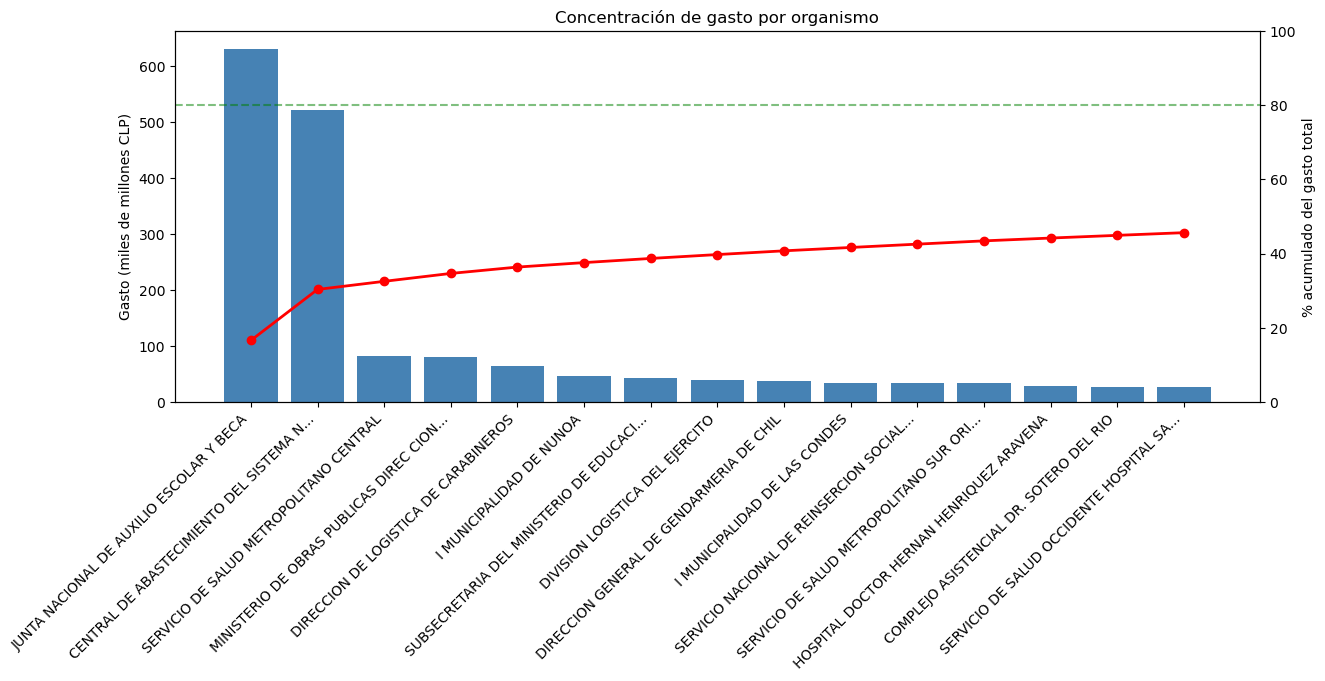

El top 15 acumula 45.6% del gasto total


In [45]:
#grafico_pareto
grafico_pareto(gasto_por_organismo['totalLineaNeto'], 'Concentración de gasto por organismo', 'pareto_organismo')

In [46]:
#top 1 y 2 % de gastos
top_2_gasto_organismos = gasto_por_organismo.head(2)['totalLineaNeto'].sum() #top 2 gastos organismos
relacion_porcentual_organismos_top2 = (top_2_gasto_organismos / total_gasto_organismos) * 100 #% top 2 gastos organismos


print(f'El top 1 de organismos concentran el: {relacion_porcentual_organismos_top1}% del gasto total.')
print(f'El top 2 de organismos concentran el: {relacion_porcentual_organismos_top2}% del gasto total.')

El top 1 de organismos concentran el: 16.604581401507605% del gasto total.
El top 2 de organismos concentran el: 30.34911195454858% del gasto total.


**Respuesta 1.1: El estado gasta de forma marcadamente concentrada en la cabeza y distribuido en la cola. Podemos ver la concentración en el top 1 y 2 de organismos (JUNAEB y CENABAST, respectivamente) y la cola, muy larga que distribuye el resto del gasto. Lo que no indica que el gasto total sea mayoritariamente efectuado por tales organismos debido que estos 2 solo ocupan 30% del gasto, dato que imposibilita destacar la hipotesis de que el estado gasta de manera concentrada. Se concluye, de hecho, que gasta de manera distribuida en una cantidad gigante de organismos pero con picos de gastos en el top 1 y top 2.**

**1.2.- ¿El estado gasta de forma fragmentada o consolidada?**

In [47]:
#.describe a OCs
tamaño_ocs = df_limpieza.groupby('ID')[['totalLineaNeto']].sum()
print(tamaño_ocs['totalLineaNeto'].describe().apply(formato_legible))

count       $401.1K
mean          $9.5M
std         $452.0M
min      $-14740112
25%         $279.0K
50%         $875.7K
75%           $2.9M
max         $139.0B
Name: totalLineaNeto, dtype: object


*La presencia de negativos indican devoluciones o cancelaciones de OCs. Se investiga el impacto de estos.*

In [48]:
#Calculamos el impacto
total_con_negativos = df_limpieza['totalLineaNeto'].sum()

total_sin_negativos = df_limpieza[df_limpieza['totalLineaNeto'] > 0]['totalLineaNeto'].sum()

diferencia = abs(total_con_negativos - total_sin_negativos)
diferencia_porcentual = (diferencia / total_con_negativos) * 100

print(f'Diferencia: ${diferencia/1e6:.1f}M ({diferencia_porcentual:.2f}%)')

Diferencia: $15.3M (0.00%)


*Dado que la diferencia es insignificante, se continúa con el análisis.*

In [49]:
#.describe a OCs
tamaño_ocs = df_limpieza.groupby('ID')[['totalLineaNeto']].sum()
print(tamaño_ocs['totalLineaNeto'].describe().apply(formato_legible))

count       $401.1K
mean          $9.5M
std         $452.0M
min      $-14740112
25%         $279.0K
50%         $875.7K
75%           $2.9M
max         $139.0B
Name: totalLineaNeto, dtype: object


*Parametros*
- Promedio $9.5M
- Mediana $875.7K
- Promedio / Mediana 10.8x
- Maxima $139B
- Maxima / Promedio 14.631x

*Se sospecha del valor maximo*

In [50]:
#Comprobación top 1
df_limpieza[df_limpieza['totalLineaNeto'] == df_limpieza['totalLineaNeto'].max()][['OrganismoPublico', 'NombreProveedor', 'totalLineaNeto']]

,OrganismoPublico,NombreProveedor,totalLineaNeto
712344,JUNTA NACIONAL DE AUXILIO ESCOLAR Y BECA,SOC ADMINISTRADORA DE CASINOS Y SERVICIOS ALIS...,1.389852e+11


*Se confirma que es un valor legitimo*

**Respuesta 1.2: Consolidado, debido a que la gran mayoria de OCs son pequeñas. Contra muy pocas OCs que dominan los grandes montos. Es decir que la mayoria del gasto está concentrado en muy pocas OCs**

**1.3.- ¿Existe un monopolio o está abierto a la competencia?**

In [51]:
#Chequeamos proveedores unicos, OCs totales, y sus relaciones.
n_proveedores = df_limpieza['NombreProveedor'].nunique()
n_ocs = df_limpieza['ID'].nunique()

print(f'Proveedores unicos: {n_proveedores:,}')
print(f'OCs totales: {n_ocs:,}')
print(f'Ratio: {n_proveedores/n_ocs:.2f}')
print(f'OCs por proveedor {n_ocs/n_proveedores:.2f}')

Proveedores unicos: 35,817
OCs totales: 401,077
Ratio: 0.09
OCs por proveedor 11.20


**Respuesta 1.3: Abierto a la competencia, porque hay en promedio 11 licitaciones que puede que gane un proveedor en un plazo de 3 meses (Que son los meses de esta muestra de datos). Tambien, considerar que el ratio alto indica que hay pocos proveedores relativos a OCs lo que indica alta concentración, sin embargo, al haber tantos proveedores se debe descartar monopolio.  En conclusión, el mercado es competitivo pero los ganadores de licitaciones tienden a repetirse a lo largo del tiempo.**

## Sintesis de pregunta 1: ¿Cómo gasta el Estado? el estado no gasta de forma uniforme ni totalmente concentrada, sino concentrado en la cabeza y distribuido en la cola. Pocos organismos, pocas OCs y proveedores recurrentes explican una porción desproporcionada del gasto, dentro de un ecosistema amplio. ##

-Organismo: El gasto total se reparte entre muchos organismos, pero con picos marcados en los dos primeros (JUNAEB y CENABAST), que concentran 30% del gasto.

-OC: La gran mayoría de las OCs son de montos pequeños, mientras que un grupo reducido de OCs grandes acumula el grueso del dinero.

-Competencia: El mercado está abierto. Hay suficientes proveedores para descartar un monopolio. Pero los ganadores de licitaciones tienden a repetirse en el tiempo. Competitivo en apariencia, con concentración real en quién termina ganando.

#### Se procede a intentar responder la segunda pregunta ¿Dónde gasta el estado? ####

*Se agregan columnas relativas a la región para facilitar la resolución de problemas.*

In [52]:
#Agregamos columnas utiles para la etapa
df_limpieza['RegionUnidadCompra'] = df['RegionUnidadCompra'] #Agregamos columna 'RegionUnidadCompra'
df_limpieza['RegionProveedor'] = df['RegionProveedor'] #Agregamos columna 'RegionProveedor'
df_limpieza.head() #Comprobación.

,ID,OrganismoPublico,sector,FechaEnvio,totalLineaNeto,NombreProveedor,Categoria,RubroN1,TotalLineaNeto_clp,RegionUnidadCompra,RegionProveedor
0,46636823,ILUSTRE MUNICIPALIDAD DE COLBUN,Municipalidades,2026-01-19,11300000.0,INVETMED,"Servicios agrícolas, pesqueros, forestales y r...","Servicios agrícolas, pesqueros, forestales y r...","11,300,000",Región del Maule,Región de Coquimbo
1,46824565,I MUNICIPALIDAD DE TEMUCO,Municipalidades,2026-01-29,750.0,PEDRO ANDRÉS GAETE VILLEGAS,"Servicios basados en ingeniería, ciencias soci...","Servicios basados en ingeniería, ciencias soci...",750,Región de la Araucanía,Región de la Araucanía
2,47646675,SERVICIO DE VIVIENDA Y URBANIZACION VII REGION,Obras Públicas,2026-01-30,2170.0,SOINTEC INGENIEROS CONSULTORES LTDA.,"Servicios profesionales, administrativos y con...","Servicios profesionales, administrativos y con...","2,170",Región del Maule,Región del Maule
3,50874555,I MUNICIPALIDAD DE SALAMANCA,Municipalidades,2026-01-28,620000.0,MIGUEL ANGEL VILLARROEL ARAYA,"Artículos para estructuras, obras y construcci...","Artículos para estructuras, obras y construcci...","620,000",Región de Coquimbo,Región de Coquimbo
4,50874555,I MUNICIPALIDAD DE SALAMANCA,Municipalidades,2026-01-28,2160000.0,MIGUEL ANGEL VILLARROEL ARAYA,"Artículos para estructuras, obras y construcci...","Artículos para estructuras, obras y construcci...","2,160,000",Región de Coquimbo,Región de Coquimbo


**2.1.- ¿Cuánto gasta el estado por categoría?**

In [53]:
#Gasto por categoria.
gasto_por_categoria = df_limpieza.groupby('Categoria')[['totalLineaNeto']].sum().sort_values('totalLineaNeto', ascending=False)
print(gasto_por_categoria.apply(lambda x: x.apply(formato_legible)))

                                                   totalLineaNeto
Categoria                                                        
Organizaciones y consultorías políticas, demogr...        $629.8B
Servicios de construcción y mantenimiento / Con...        $265.3B
Desconocido                                               $161.8B
Medicamentos y productos farmacéuticos / Medica...        $125.6B
Servicios de limpieza industrial / Eliminación ...        $117.6B
...                                                           ...
Artículos de fabricación y producción / Piezas ...          $1.1K
Artículos de fabricación y producción / Conjunt...           $878
Servicios de perforación de minería, petróleo y...           $270
Organizaciones y consultorías políticas, demogr...             $8
Organizaciones sociales, laborales y clubes / O...             $2

[1871 rows x 1 columns]


In [54]:
#tops y pct
top_10_gasto_categoria = gasto_por_categoria.head(10)['totalLineaNeto'].sum()
top_5_gasto_categoria = gasto_por_categoria.head(5)['totalLineaNeto'].sum()
top_1_gasto_categoria = gasto_por_categoria.head(1)['totalLineaNeto'].sum()

total_gasto_categoria = gasto_por_categoria['totalLineaNeto'].sum()
relacion_porcentual_categorias_top10 = (top_10_gasto_categoria / total_gasto_categoria) * 100
relacion_porcentual_categorias_top5 = (top_5_gasto_categoria / total_gasto_categoria) * 100
relacion_porcentual_categorias_top1 = (top_1_gasto_categoria / total_gasto_categoria) * 100

print(f'El top 10 de categorias concentran el: {relacion_porcentual_categorias_top10}% del gasto')
print(f'El top 5 de categorias concentran el: {relacion_porcentual_categorias_top5}% del gasto')
print(f'El top 1 de categorias concentran el: {relacion_porcentual_categorias_top1}% del gasto')

El top 10 de categorias concentran el: 44.977350389383695% del gasto
El top 5 de categorias concentran el: 34.191928113741085% del gasto
El top 1 de categorias concentran el: 16.563381826132435% del gasto


*Se realiza grafico para mejor visualización.*

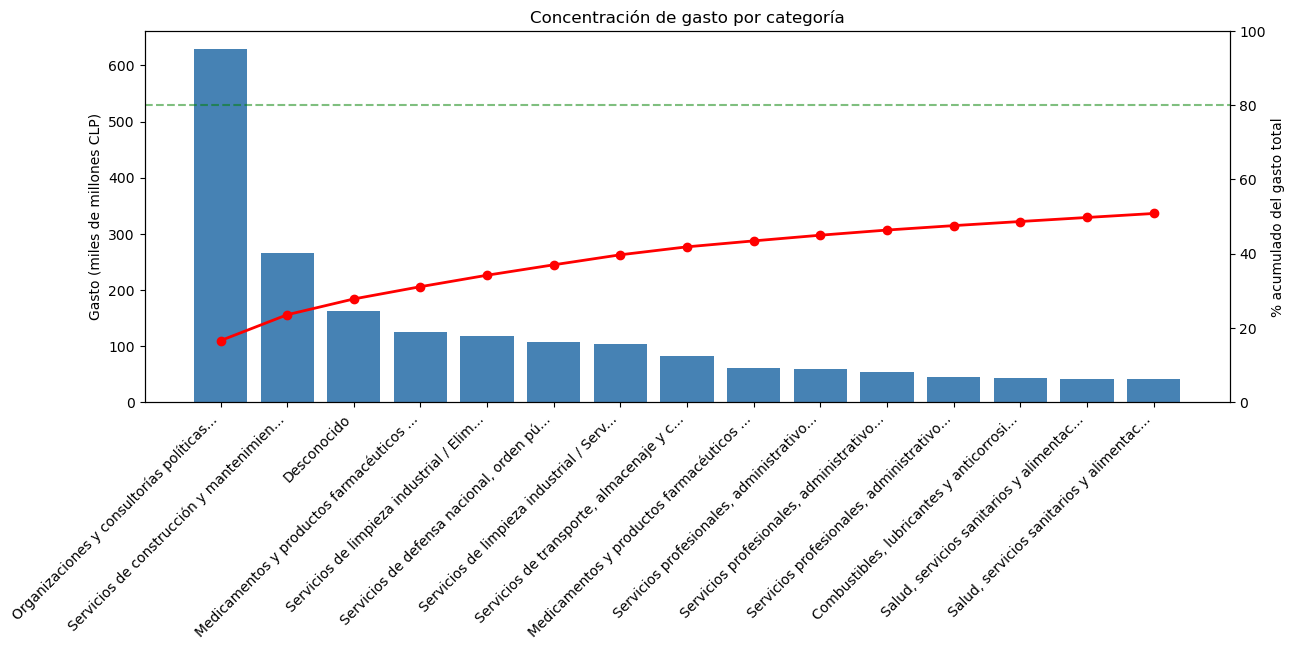

El top 15 acumula 50.8% del gasto total


In [55]:
#Grafico de Pareto
grafico_pareto(gasto_por_categoria['totalLineaNeto'], 'Concentración de gasto por categoría', 'pareto_categoria')

**Respuesta 2.1: En este caso, el top 1, es decir, la categoria 'Organizaciones y Consultorias politicas' es significativamente más grande que el top 2, por lo que nos encontramos con un caso de concentración ligera que abarca un 16% del gasto total. Y considerando que el top 10 ni siquiera abarca el 80% del gasto, nos permite concluir que el gasto es bastante distribuido. La recomendación a un potencial proveedor es: Entrar al mercado de las Consultorías dado su gran tamaño mercantil sin descartar opciones secundarias como el area de construcción, salud o incluso limpieza industrial. Tambien considerar que al entrar en una categoria de menor tamaño se corre el riesgo de competir en un mercado fragmentado.
En resumen, el estado gasta un 16,5% en 'Organizaciones y Consultorias politicas', dejando no tanto por detras al resto de las categorias, lo que permite un amplia distribución de mercado.**

**2.2.- ¿Cuánto gasta el estado por región?**

In [56]:
#Gastos por región considerando desde donde vienen la OC y no la región del proveedor.
gasto_por_region = df_limpieza.groupby('RegionUnidadCompra')[['totalLineaNeto']].sum().sort_values('totalLineaNeto', ascending=False)
print(gasto_por_region.apply(lambda x: x.apply(formato_legible)))

                                                 totalLineaNeto
RegionUnidadCompra                                             
Región Metropolitana de Santiago                       $2331.8B
Región de Valparaíso                                    $216.3B
Región del Biobío                                       $201.6B
Región de la Araucanía                                  $168.5B
Región de los Lagos                                     $128.8B
Región del Maule                                        $128.1B
Región de Coquimbo                                       $89.7B
Región del Libertador General Bernardo O´Higgins         $85.1B
Región de Antofagasta                                    $81.8B
Región Aysén del General Carlos Ibáñez del Campo         $61.5B
Región del Ñuble                                         $61.3B
Región de Los Ríos                                       $58.6B
Región de Tarapacá                                       $42.1B
Región de Atacama                       

*Se considera filtrar y agrupar por palabra clave debido a incongruencias en el formato.*

In [57]:
#Todos los valores de 'RegionUnidadCompra'
print(df['RegionUnidadCompra'].value_counts(dropna=False))

RegionUnidadCompra
Región Metropolitana de Santiago                    298359
Región de Valparaíso                                113008
Región del Biobío                                   108688
Región de los Lagos                                  85008
Región de la Araucanía                               81542
Región del Maule                                     65714
Región del Libertador General Bernardo O´Higgins     50028
Región de Coquimbo                                   47187
Región del Ñuble                                     43809
Región de Los Ríos                                   39819
Región de Magallanes y de la Antártica               34983
Región de Antofagasta                                28260
Región de Tarapacá                                   27972
Región Aysén del General Carlos Ibáñez del Campo     25076
Región de Atacama                                    23740
Región de Arica y Parinacota                         19504
Metropolitana                        

*Se consolida creando función que detecte palabra clave y transformé a el nombre estandar de la región.*

In [58]:
mapa_regiones = {
    'Metropolitana': 'Región Metropolitana de Santiago',
    'Valparaiso': 'Región de Valparaiso',
    'Bio-Bío': 'Región del Biobío',
    'Los Lagos': 'Región de los Lagos',
    'Araucania': 'Región de la Araucanía',
    'Maule': 'Región del Maule',
    "Lib. Gral. Bdo. O'Higgins": 'Región del Libertador General Bernardo O´Higgins',
    'Coquimbo': 'Región de Coquimbo',
    'Ñuble': 'Región del Ñuble',
    'Los Ríos': 'Región de Los Ríos',
    'Magallanes y Antártica': 'Región de Magallanes y de la Antártica',
    'Antofagasta': 'Región de Antofagasta',
    'Tarapacá': 'Región de Tarapacá',
    'Aysen': 'Región Aysén del General Carlos Ibañez del Campo',
    'Atacama': 'Región de Atacam',
    'Arica y Parinacota': 'Región de Arica y Parinacota'
}
df_limpieza['RegionUnidadCompra'] = df_limpieza['RegionUnidadCompra'].replace(mapa_regiones)

print('Regiones únicas tras consolidar:', df_limpieza['RegionUnidadCompra'].nunique()) #Comprobación

Regiones únicas tras consolidar: 26


*Consolidación fallida por motivos desconocidos.*

In [59]:
#test
oficiales = set(mapa_regiones.values())
actuales = set(df_limpieza['RegionUnidadCompra'].dropna().unique())
sobrantes = actuales - oficiales
for r in sorted(sobrantes):
    print(repr(r)) #presnetación formal que lee la python

'Araucanía'
'Aysén'
'Bío-Bío'
'Región Aysén del General Carlos Ibáñez del Campo'
'Región de Antofagasta '
'Región de Atacama '
'Región de Coquimbo '
'Región de Tarapacá  '
'Región de Valparaíso '
'Región de la Araucanía '
'Región de los Lagos '
'Región del Biobío '
'Región del Maule '
'Valparaíso'


*La asimilación fallo por no haber eliminado espacios extras al cargar el dataset.* 
- Nota: Lección aprendida.

In [60]:
#Funcion que asimila por palabra clave
import unicodedata

def normaliza(texto): #Aplca función normalize de libreria unicodedata
    '''transforma a: minus, no tildes, no espacios extras'''
    texto = str(texto).lower().strip()
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto)
                    if unicodedata.category(c) != 'Mn')
    return texto
claves = {
    'metropolitana': 'Región Metropolitana de Santiago',
    'valparaiso': 'Región de Valparaíso',
    'bio': 'Región del Biobío',
    'lagos': 'Región de los Lagos',
    'araucania': 'Región de la Araucanía',
    'maule': 'Región del Maule',
    'higgins': 'Región del Libertador General Bernardo O´Higgins',
    'coquimbo': 'Región de Coquimbo',
    'nuble': 'Región del Ñuble',
    'rios': 'Región de Los Ríos',
    'magallanes': 'Región de Magallanes y de la Antártica',
    'antofagasta': 'Región de Antofagasta',
    'tarapaca': 'Región de Tarapacá',
    'aysen': 'Región Aysén del General Carlos Ibáñez del Campo',
    'atacam': 'Región de Atacama',
    'arica': 'Región de Arica y Parinacota',
}

def canoniza_region(valor):
    n= normaliza(valor)
    for clave, oficial in claves.items():
        if clave in n:
            return oficial
    return valor

df_limpieza['RegionUnidadCompra'] = df_limpieza['RegionUnidadCompra'].apply(canoniza_region)
print('Regiones únicas:', df_limpieza['RegionUnidadCompra'].nunique())

Regiones únicas: 16


*Asimilación exitosa.*

In [61]:
#Gastos por región considerando desde donde vienen la OC y no la región del proveedor.
gasto_por_region = df_limpieza.groupby('RegionUnidadCompra')[['totalLineaNeto']].sum().sort_values('totalLineaNeto', ascending=False)
print(gasto_por_region.apply(lambda x: x.apply(formato_legible)))

                                                 totalLineaNeto
RegionUnidadCompra                                             
Región Metropolitana de Santiago                       $2343.6B
Región de Valparaíso                                    $222.0B
Región del Biobío                                       $207.8B
Región de la Araucanía                                  $170.8B
Región de los Lagos                                     $134.7B
Región del Maule                                        $131.2B
Región de Coquimbo                                       $90.1B
Región del Libertador General Bernardo O´Higgins         $85.5B
Región de Antofagasta                                    $82.1B
Región del Ñuble                                         $61.8B
Región Aysén del General Carlos Ibáñez del Campo         $61.7B
Región de Los Ríos                                       $59.0B
Región de Tarapacá                                       $42.9B
Región de Atacama                       

*Se procede a inspeccionar concentración*

In [62]:
#tops y pct
top_10_region = gasto_por_region.head(10)['totalLineaNeto'].sum()
top_5_region = gasto_por_region.head(5)['totalLineaNeto'].sum()
top_1_region = gasto_por_region.head(1)['totalLineaNeto'].sum()


total_regiones = gasto_por_region['totalLineaNeto'].sum()
relacion_porcentual_regiones_top10 = (top_10_region / total_regiones) * 100
relacion_porcentual_regiones_top5 = (top_5_region / total_regiones) * 100
relacion_porcentual_regiones_top1 = (top_1_region / total_regiones) * 100


print(f'El top 10 de regiones concentran el: {relacion_porcentual_regiones_top10}% del gasto')
print(f'El top 5 de regiones concentran el: {relacion_porcentual_regiones_top5}% del gasto')
print(f'El top 1 de regiones concentran el: {relacion_porcentual_regiones_top1}% del gasto')

El top 10 de regiones concentran el: 92.81904138485986% del gasto
El top 5 de regiones concentran el: 80.9668286949884% del gasto
El top 1 de regiones concentran el: 61.630528508563586% del gasto


*Se realiza grafico para visualizar concentración extrema.*

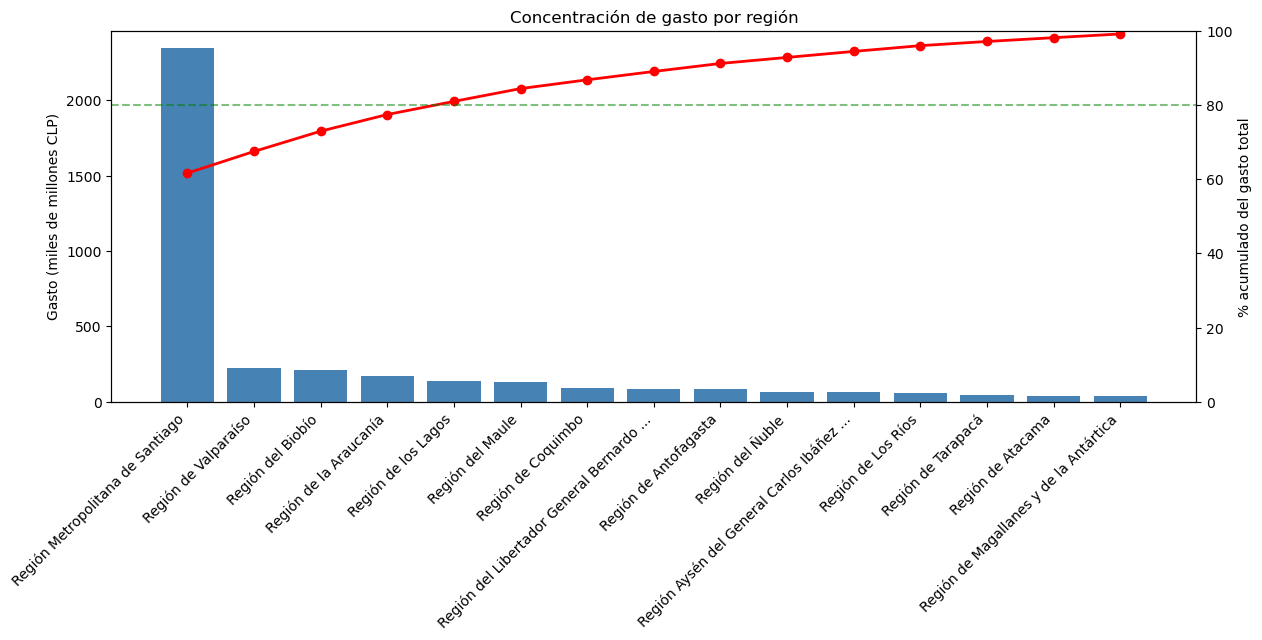

El top 15 acumula 99.1% del gasto total


In [63]:
#Grafico de Pareto
grafico_pareto(gasto_por_region['totalLineaNeto'],    'Concentración de gasto por región',    'pareto_region')

**Respuesta 2.2: El estado concentra en la Región Metropolitana el 61.63% del gasto total. Y el 80% acumulado apenas al llegar al top 5. Mientras que en el resto de regiones se contiene un gasto muy reducido. Cabe destacar que se presume que este gasto está estrechamente vinculado a la población de la región. Sin embargo, para un proveedor que busque entrar en la mercado publico se le puede esclarecer que: 1) Si busca entrar en Santiago se aventurará en el mercado principal pero que por el mismo motivo se verá con mucha competencia. Y que 2.-Si prefiere entrar en mercado publico de regiones se vera con un mercado mucho más pequeño pero tambien menos competido.**

**2.3.- ¿Cuánto gasta el estado por rubro?**

In [64]:
#Gastos por rubro.
gasto_por_rubro = df_limpieza.groupby('RubroN1')[['totalLineaNeto']].sum().sort_values('totalLineaNeto', ascending=False)
print(gasto_por_rubro.apply(lambda x: x.apply(formato_legible)))

                                                   totalLineaNeto
RubroN1                                                          
Organizaciones y consultorías políticas, demogr...        $648.3B
Medicamentos y productos farmacéuticos                    $491.4B
Servicios de construcción y mantenimiento                 $342.9B
Equipamiento y suministros médicos                        $292.0B
Servicios de limpieza industrial                          $249.7B
Salud, servicios sanitarios y alimentación                $190.2B
Servicios profesionales, administrativos y cons...        $183.7B
Desconocido                                               $161.8B
Servicios de defensa nacional, orden público y ...        $134.0B
Servicios de transporte, almacenaje y correo              $133.5B
Equipamiento para laboratorios                             $83.7B
Tecnologías de la información, telecomunicacion...         $67.2B
Servicios basados en ingeniería, ciencias socia...         $60.2B
Servicios 

In [65]:
#tops y pct
top_10_rubros = gasto_por_rubro.head(10)['totalLineaNeto'].sum()
top_5_rubros = gasto_por_rubro.head(5)['totalLineaNeto'].sum()
top_1_rubros = gasto_por_rubro.head(1)['totalLineaNeto'].sum()


total_regiones = gasto_por_rubro['totalLineaNeto'].sum()
relacion_porcentual_rubros_top10 = (top_10_rubros / total_regiones) * 100
relacion_porcentual_rubros_top5 = (top_5_rubros / total_regiones) * 100
relacion_porcentual_rubros_top1 = (top_1_rubros / total_regiones) * 100


print(f'El top 10 de rubros concentran el: {relacion_porcentual_rubros_top10}% del gasto')
print(f'El top 5 de rubros concentran el: {relacion_porcentual_rubros_top5}% del gasto')
print(f'El top 1 de rubros concentran el: {relacion_porcentual_rubros_top1}% del gasto')

El top 10 de rubros concentran el: 74.3539950554809% del gasto
El top 5 de rubros concentran el: 53.23209892764231% del gasto
El top 1 de rubros concentran el: 17.047609023551995% del gasto


*Se realiza grafico para visualizar concentración*

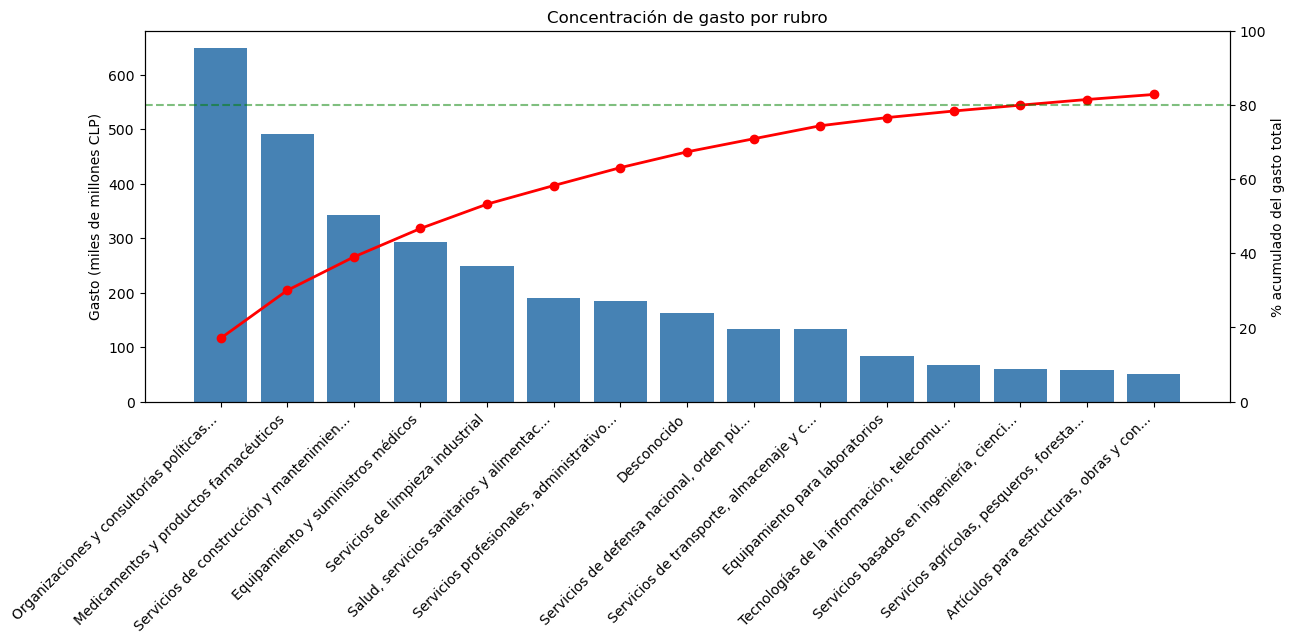

El top 15 acumula 82.8% del gasto total


In [66]:
#Grafico de Pareto (Poco legible)
grafico_pareto(gasto_por_rubro['totalLineaNeto'],     'Concentración de gasto por rubro',     'pareto_rubro')

*Se chequean diferencias reales entre 'Rubro' y 'Categoria'*

In [67]:
#Diferencias rubro y categorias
print('Top 10 rubros', gasto_por_rubro.head(10).apply(lambda x: x.apply(formato_legible))) #top 10 rubros.
print('='*100) #Separador visual
print('Top 10 categorias', gasto_por_categoria.head(10).apply(lambda x: x.apply(formato_legible))) #top 10 categorias.
print('='*100) #Separador visual
print('Comparacion porcentual Rubros vs Categorias')
print(f'Rubros:             Top 5 = {53.2:.1f}%, Top 10 = {74.4:.1f}%')
print(f'Categorias:         Top 5 = {34.2:.1f}%, Top 10 = {45.0:.1f}%')

Top 10 rubros                                                    totalLineaNeto
RubroN1                                                          
Organizaciones y consultorías políticas, demogr...        $648.3B
Medicamentos y productos farmacéuticos                    $491.4B
Servicios de construcción y mantenimiento                 $342.9B
Equipamiento y suministros médicos                        $292.0B
Servicios de limpieza industrial                          $249.7B
Salud, servicios sanitarios y alimentación                $190.2B
Servicios profesionales, administrativos y cons...        $183.7B
Desconocido                                               $161.8B
Servicios de defensa nacional, orden público y ...        $134.0B
Servicios de transporte, almacenaje y correo              $133.5B
Top 10 categorias                                                    totalLineaNeto
Categoria                                                        
Organizaciones y consultorías políticas, dem

*Naturalmente se entiende que 'Rubros' es una categoria principal y 'Categorias' es una sub-categoria de 'Rubros'. Esto explica la mayor concentración en 'Rubros' que en 'Categorias'.*

**Respuesta 2.3: Se aprecia que el estado gasta de manera más distribuida que en otros casos. Tambien cabe destacar que el margen del 80% acumulado es alcanzado por el top 14. Cabe destacar el rubro 'Desconocido' se insertó de manera artificial para cubrir valores nulos; su investigación posterior reveló que predominan los servicios locales de educación (100% de ordenes sin clasifica) y, en menos medida, Gendarmeria (61% de ordenes sin clasificar), señalando una falla de captura.**

## Sintesis de pregunta 2: ¿Cuánto gasta el estado por categoría? El estado gasta de manera distribuida por categoría, pero altamente concentrada geograficamente. No hay una categoria dominante que acapare mercado, sino que el gasto se reparte entre multiples rubros. ##
-Categoría: El gasto de distribuye ampliamente entre categorías pero 'Organizaciones y Consultorias politicas' lideran con un 16% del gasto. Sin embargo, el top 10 de categorías no alcanza el 80% del gasto total. Lo que significa que es un mercado abierto con multiples oportunidades.

-Región: La concentración geografica es pronunciada. La Región Metropolitana acumula el 61.6% del gasto total. Mientras que el resto de regiones se reparte el 39% restante. El 80% acumulado se alcanza apenas en el top 5.

-Proveedores: Existen 2 estrategias viables. 1) Entrar en una categoría pequeña, lo que implicaria menos competencia pero con mercados reducidos o 2) Entrar en la RM con su acceso a el mercado principal y con competencia intensa. Tambien entender que las regiones ofrecen mercados pequeños e insaturados.

## Se procede a intentar responder la tercera pregunta ¿Qué oportunidades tienen los proveedores? ##

**3.1.- ¿Qué organismos tienen pocos proveedores y que por ende es más facil entrar?**

In [68]:
#Organismos y proveedores en #
organismos_n_proveedores_unicos = df_limpieza.groupby('OrganismoPublico')['NombreProveedor'].nunique().sort_values(ascending=False)
print(organismos_n_proveedores_unicos)

OrganismoPublico
UNIVERSIDAD DE CHILE                                                     2399
DIRECCION DE ABASTECIMIENTO DE LA ARMADA                                 2243
DIVISION LOGISTICA DEL EJERCITO                                          2042
DIRECCION DE LOGISTICA DE CARABINEROS                                    1649
SERVICIO NACIONAL DE SALUD HOSPITAL DE C                                 1148
                                                                         ... 
FUNDACION DE CULTURA, TURISMO Y DEPORTES DE LA MUNICIPALIDAD DE MARIA       1
CORPORACIÓN MUNICIPAL DE DESARROLLO SOCIAL DE LOS MUERMOS                   1
ASOCIACION DE MUNICIPALIDADES DE LA REGION DE COQUIMBO                      1
TRIBUNAL ELECTORAL REGIONAL SEPTIMA REGI                                    1
ACADEMIA NACIONAL DE ESTUDIOS POLITICOS Y ESTRATEGICOS                      1
Name: NombreProveedor, Length: 1146, dtype: int64


In [69]:
#Top organismos con menos proveedores
bottom_10_organismos_n_proveedores_unicos = organismos_n_proveedores_unicos.tail(10)
print(bottom_10_organismos_n_proveedores_unicos)

OrganismoPublico
CORP MUNICIPAL DE SERVICIOS Y DESARROLLO                                 1
JUNTA NACIONAL DE CUERPOS DE BOMBEROS DE CHILE                           1
ASOCIACIÓN DE MUNICIPALIDADES CORDILLERANAS DE LA ARAUCANÍA              1
ASOCIACION DE MUNICIPALIDADES NAHUELBUTA                                 1
SERVICIO NACIONAL DE MENORES                                             1
FUNDACION DE CULTURA, TURISMO Y DEPORTES DE LA MUNICIPALIDAD DE MARIA    1
CORPORACIÓN MUNICIPAL DE DESARROLLO SOCIAL DE LOS MUERMOS                1
ASOCIACION DE MUNICIPALIDADES DE LA REGION DE COQUIMBO                   1
TRIBUNAL ELECTORAL REGIONAL SEPTIMA REGI                                 1
ACADEMIA NACIONAL DE ESTUDIOS POLITICOS Y ESTRATEGICOS                   1
Name: NombreProveedor, dtype: int64


*La presencia de organismos con 1 solo proveedor se puede considerar como outlier.*

*Se procede a hacer descarte de organismos con metodo IQR + Upper/Lower Limit.* 

In [70]:
#IQR
p25 = organismos_n_proveedores_unicos.quantile(0.25)
p75 = organismos_n_proveedores_unicos.quantile(0.75)
iqr = p75 - p25

#Upper/Lower Limit
upper_limit = p75 + 1.5 * iqr
lower_limit = p25 - 1.5 * iqr
print(lower_limit)
print(upper_limit)

-186.0
388.0


In [71]:
#Aplicamos metodo IQR + Limites
organismos_n_proveedores_unicos_sin_outliers = organismos_n_proveedores_unicos[(organismos_n_proveedores_unicos >= lower_limit) & (organismos_n_proveedores_unicos <= upper_limit)]
print(organismos_n_proveedores_unicos_sin_outliers)

OrganismoPublico
SERVICIO DE SALUD SUR HOSPITAL EXEQUIEL                                  381
SERVICIO SALUD ARAUCANIA NORTE HOSPITAL VICTORIA                         379
SERVICIO DE SALUD ANTOFAGASTA HOSPITAL L                                 377
I MUNICIPALIDAD DE TOME                                                  372
Hospital de Melipilla                                                    370
                                                                        ... 
FUNDACION DE CULTURA, TURISMO Y DEPORTES DE LA MUNICIPALIDAD DE MARIA      1
CORPORACIÓN MUNICIPAL DE DESARROLLO SOCIAL DE LOS MUERMOS                  1
ASOCIACION DE MUNICIPALIDADES DE LA REGION DE COQUIMBO                     1
TRIBUNAL ELECTORAL REGIONAL SEPTIMA REGI                                   1
ACADEMIA NACIONAL DE ESTUDIOS POLITICOS Y ESTRATEGICOS                     1
Name: NombreProveedor, Length: 1074, dtype: int64


*Se comete error al usar metodo IQR + Limites. Se procede a usar metodo manual.*

In [72]:
#Aplicamos metodo manual
organismos_n_proveedores_unicos_mayor_a_5 = organismos_n_proveedores_unicos[organismos_n_proveedores_unicos >= 10]
organismos_n_proveedores_unicos_mayor_a_5.tail(20)

OrganismoPublico
DELEGACIÓN PRESIDENCIAL PROVINCIAL DE MELIPILLA                           11
CORPORACION CULTURAL DE PADRE LAS CASAS                                   11
SUBSECRETARIA DE TURISMO                                                  11
DELEGACIÓN PRESIDENCIAL PROVINCIAL DE CORDILLERA                          10
DELEGACIÓN PRESIDENCIAL PROVINCIAL DE CHAÑARAL                            10
Corporación Municipal de Cultura de San Clemente                          10
CORPORACION DE DESARROLLO DE MAGALLANES Y DE LA ANTARTICA CHILENA - CO    10
CORPORACION MUNICIPAL DE DESARROLLO COMUNAL Y PRODUCTIVO DE LICANTEN      10
DELEGACIÓN PRESIDENCIAL PROVINCIAL DE MAIPO                               10
SERVICIO LOCAL DE EDUCACIÓN PÚBLICA ANTOFAGASTA                           10
DELEGACIÓN PRESIDENCIAL PROVINCIAL DE ÚLTIMA ESPERANZA                    10
ASOCIACION DE MUNICIPALIDADES BIO BIO CENTRO                              10
CORPORACION MUNICIPAL DE DESARROLLO ECONOMICO CULTURA Y DEP

**Respuesta 3.1: Dada la gran cantidad de organismos con pocos proveedores se procede a avanzar a la siguiente pregunta con el fin de alcanzar una conclusión más util.**

**3.2.- ¿Qué categorías tienen mucho gasto y tambien tienen pocos proveedores?**

In [73]:
#Creamos una nueva tabla para el analisis
df_analisis = df_limpieza.groupby('Categoria').agg({
    'NombreProveedor': 'nunique', #Proveedor unico
    'totalLineaNeto': 'sum'}) #Monto total
df_analisis.head() #Comprobación.

,NombreProveedor,totalLineaNeto
Categoria,,
"Alimentos, bebidas y tabaco / Aceites y grasas comestibles / Aceites vegetales y grasas comestibles",172,2.037380e+08
"Alimentos, bebidas y tabaco / Aceites y grasas comestibles / Grasas y aceites animales comestibles",59,2.601253e+07
"Alimentos, bebidas y tabaco / Alimentos preparados y conservados / Acompañamientos preparados",198,3.591597e+08
"Alimentos, bebidas y tabaco / Alimentos preparados y conservados / Bebidas y comidas infantiles",63,9.656538e+07
"Alimentos, bebidas y tabaco / Alimentos preparados y conservados / Empanadas, tartas y pies",149,1.341826e+08


In [74]:
#Empezamos el analisis
df_analisis.columns = ['proveedores', 'gasto'] #Columnas
#Definimos el analisis
resultado_analisis = df_analisis[
    (df_analisis['gasto'] >= df_analisis['gasto'].quantile(0.75)) & #Gasto mayor que el cuartil 3
    (df_analisis['proveedores'] <= df_analisis['proveedores'].quantile(0.25)) #Proveedores menores que el cuartil 1
].sort_values('gasto', ascending=False)
#Legibilizamos 'gasto'
resultado_analisis['gasto'] = resultado_analisis['gasto'].apply(formato_legible)
print(resultado_analisis)

                                                    proveedores    gasto
Categoria                                                               
Equipamiento y suministros médicos / Productos ...            4    $8.2B
Servicios financieros, pensiones y seguros / Ba...            3    $7.1B
Servicios agrícolas, pesqueros, forestales y re...            7    $4.6B
Medicamentos y productos farmacéuticos / Medica...            6    $1.3B
Educación, formación, entrenamiento y capacitac...            7  $967.0M
Organizaciones y consultorías políticas, demogr...            6  $959.5M
Equipamiento y suministros médicos / Productos ...            4  $848.6M
Servicios agrícolas, pesqueros, forestales y re...            6  $762.5M
Medicamentos y productos farmacéuticos / Medica...            5  $611.2M
Servicios profesionales, administrativos y cons...            5  $544.9M
Obras / Obras Mayores / Obra Civil                            1  $542.9M


*Se obtienen resultados adecuados.*

*¿Y rubros?*

In [75]:
#Creamos una nueva tabla para el analisis 2
df_analisis_2 = df_limpieza.groupby('RubroN1').agg({
    'NombreProveedor': 'nunique', #Proveedor unico
    'totalLineaNeto': 'sum'}) #Monto total
df_analisis_2.head() #Comprobación.

,NombreProveedor,totalLineaNeto
RubroN1,,
"Alimentos, bebidas y tabaco",1993,5.040922e+10
Artículos de electrónica,523,7.025362e+08
Artículos de fabricación y producción,2431,1.097347e+10
Artículos eléctricos y de iluminación,1744,2.079366e+10
"Artículos para estructuras, obras y construcciones",3403,5.142602e+10


In [76]:
#Empezamos el analisis 2
df_analisis_2.columns = ['proveedores', 'gasto'] #Columnas
#Definimos el analisis
resultado_analisis_2 = df_analisis_2[
    (df_analisis_2['gasto'] >= df_analisis_2['gasto'].quantile(0.75)) & #Gasto mayor que el cuartil 3
    (df_analisis_2['proveedores'] <= df_analisis_2['proveedores'].quantile(0.25)) #Proveedores menores que el cuartil 1
].sort_values('gasto', ascending=False)
#Legibilizamos 'gasto'
resultado_analisis_2['gasto'] = resultado_analisis_2['gasto'].apply(formato_legible)
print(resultado_analisis_2)

                                                    proveedores    gasto
RubroN1                                                                 
Servicios de defensa nacional, orden público y ...          549  $134.0B


*Se suaviza el criterio bajando el limite superior y subiendo el limite inferior.*

In [77]:
#Empezamos el analisis 2 suavizado
df_analisis_2.columns = ['proveedores', 'gasto'] #Columnas
#Definimos el analisis
resultado_analisis_2 = df_analisis_2[
    (df_analisis_2['gasto'] >= df_analisis_2['gasto'].quantile(0.6)) & 
    (df_analisis_2['proveedores'] <= df_analisis_2['proveedores'].quantile(0.4))
].sort_values('gasto', ascending=False)
#Legibilizamos 'gasto'
resultado_analisis_2['gasto'] = resultado_analisis_2['gasto'].apply(formato_legible)
#Se define el ancho de columna
print(resultado_analisis_2)

                                                    proveedores    gasto
RubroN1                                                                 
Organizaciones y consultorías políticas, demogr...          943  $648.3B
Medicamentos y productos farmacéuticos                      874  $491.4B
Desconocido                                                 781  $161.8B
Servicios de defensa nacional, orden público y ...          549  $134.0B
Combustibles, lubricantes y anticorrosivos                  909   $45.9B
Educación, formación, entrenamiento y capacitación          775   $40.7B
Servicios básicos y de información pública                  785   $26.3B


**Respuesta 3.2: Según el analisis, el top 10 de categorias con pocos proveedores y mucho gasto es:**

| Categoría | Proveedores | Gasto |
|-----------|:-----------:|------:|
| Equipamiento y suministros médicos / Productos ... | 4 | $8.2B |
| Servicios financieros, pensiones y seguros / Ba... | 3 | $7.1B |
| Servicios agrícolas, pesqueros, forestales y re... | 7 | $4.6B |
| Medicamentos y productos farmacéuticos / Medica... | 6 | $1.3B |
| Educación, formación, entrenamiento y capacitac... | 7 | $967.0M |
| Organizaciones y consultorías políticas, demogr... | 6 | $959.5M |
| Equipamiento y suministros médicos / Productos ... | 4 | $848.6M |
| Servicios agrícolas, pesqueros, forestales y re... | 6 | $762.5M |
| Medicamentos y productos farmacéuticos / Medica... | 5 | $611.2M |
| Servicios profesionales, administrativos y cons... | 5 | $544.9M |

**Pero si hablamos de rubros:**

| Rubros | Proveedores | Gasto |
|-----------|:-----------:|------:|
| Organizaciones y consultorías políticas, demogr... | 943 | $648.3B |
| Medicamentos y productos farmacéuticos | 874 | $491.4B |
| Desconocido | 781 | $161.8B |
| Servicios de defensa nacional, orden público y ... | 549 | $134.0B |
| Combustibles, lubricantes y anticorrosivos | 909 | $45.9B |
| Educación, formación, entrenamiento y capacitación | 775 | $40.7B |
| Servicios básicos y de información pública | 785 | $26.3B |

**3.3.- ¿Que nichos especificos no están saturados?**

*Se trabaja con OCs por lo que es prudente ocupar 'MontoTotalOC_PesosChilenos' en vez de 'totalLineaNeto'. Dado que fue descartada anteriormente se procede a cargar el dataset denuevo.*

In [78]:
archivos = glob.glob('C:/Users/OAD/Documents/mercado-publico-eda/mercado-publico-eda/data/raw/*.csv')
df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)

df = df.drop_duplicates(subset=['ID', 'IDItem'])
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

df['oc_clp'] = a_numero(df['MontoTotalOC_PesosChilenos'])
df['linea_clp'] = a_numero(df['totalLineaNeto'])

C:\Users\OAD\AppData\Local\Temp\ipykernel_17464\1328661659.py:2: DtypeWarning: Columns (21,31,53,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)
C:\Users\OAD\AppData\Local\Temp\ipykernel_17464\1328661659.py:2: DtypeWarning: Columns (21,31,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)
C:\Users\OAD\AppData\Local\Temp\ipykernel_17464\1328661659.py:2: DtypeWarning: Columns (21,31,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f, sep=';', encoding='Latin-1') for f in archivos], ignore_index=True)


In [79]:
#Hacer equivalente 1 fila a 1 OC
nivel_oc = df.groupby('ID').agg(
    Categoria=('Categoria', 'first'),
    CodigoProveedor=('CodigoProveedor', 'first'),
    monto=('oc_clp', 'first')
).reset_index(drop=True)

#Agrupar OCs por categoria
saturacion = nivel_oc.groupby('Categoria').agg(
    num_proveedores=('CodigoProveedor', 'nunique'),
    dinero_total=('monto', 'sum')
).reset_index()

#Ratio dinero-proveedor
saturacion['dinero_por_proveedor'] = (saturacion['dinero_total'] / saturacion['num_proveedores'])

#Nichos no saturados
nichos_oportunidad = saturacion[
    (saturacion['num_proveedores'] < saturacion['num_proveedores'].quantile(0.25)) &
    (saturacion['dinero_total'] > saturacion['dinero_total'].median())
].sort_values('dinero_por_proveedor', ascending=False)

#resultado
nichos_oportunidad

,Categoria,num_proveedores,dinero_total,dinero_por_proveedor
564,Equipamiento y suministros médicos / Productos...,4,9.766776e+09,2.441694e+09
1639,"Servicios financieros, pensiones y seguros / B...",3,7.122170e+09,2.374057e+09
1187,Obras / Obras Mayores / Obra Civil,1,6.460949e+08,6.460949e+08
576,Equipamiento y suministros médicos / Productos...,2,8.485702e+08,4.242851e+08
1118,Medicamentos y productos farmacéuticos / Medic...,5,1.513387e+09,3.026775e+08
1080,Medicamentos y productos farmacéuticos / Medic...,5,7.273372e+08,1.454674e+08
580,Equipamiento y suministros médicos / Productos...,3,4.160049e+08,1.386683e+08
1219,"Organizaciones y consultorías políticas, demog...",1,1.376400e+08,1.376400e+08
1546,"Servicios de perforación de minería, petróleo ...",2,2.669872e+08,1.334936e+08
1547,"Servicios de perforación de minería, petróleo ...",3,3.893098e+08,1.297699e+08


*Se legibilizan las columnas con notación cientifica*

In [80]:
#Definir formato_legible e imprimir output
def formato_legible(valor):
    if pd.isna(valor):
        return '-'
    return f'${valor:,.0f}'.replace(',', '.')

nichos_oportunidad_legible = nichos_oportunidad.copy()
nichos_oportunidad_legible['dinero_total'] = nichos_oportunidad_legible['dinero_total'].apply(formato_legible)
nichos_oportunidad_legible['dinero_por_proveedor'] = nichos_oportunidad_legible['dinero_por_proveedor'].apply(formato_legible)

nichos_oportunidad_legible

,Categoria,num_proveedores,dinero_total,dinero_por_proveedor
564,Equipamiento y suministros médicos / Productos...,4,$9.766.775.858,$2.441.693.965
1639,"Servicios financieros, pensiones y seguros / B...",3,$7.122.169.599,$2.374.056.533
1187,Obras / Obras Mayores / Obra Civil,1,$646.094.879,$646.094.879
576,Equipamiento y suministros médicos / Productos...,2,$848.570.155,$424.285.078
1118,Medicamentos y productos farmacéuticos / Medic...,5,$1.513.387.260,$302.677.452
1080,Medicamentos y productos farmacéuticos / Medic...,5,$727.337.187,$145.467.437
580,Equipamiento y suministros médicos / Productos...,3,$416.004.866,$138.668.289
1219,"Organizaciones y consultorías políticas, demog...",1,$137.640.000,$137.640.000
1546,"Servicios de perforación de minería, petróleo ...",2,$266.987.154,$133.493.577
1547,"Servicios de perforación de minería, petróleo ...",3,$389.309.824,$129.769.941


*Se ajusta el ancho de la columna 'Categoria'.*

In [81]:
#colwidth
pd.set_option('display.max_colwidth', None)
nichos_oportunidad_legible

,Categoria,num_proveedores,dinero_total,dinero_por_proveedor
564,Equipamiento y suministros médicos / Productos para imágenes y de medicina nuclear / Artículos del acelerador lineal de terapia de radiación de intensidad modulada (IMRT) l,4,$9.766.775.858,$2.441.693.965
1639,"Servicios financieros, pensiones y seguros / Banca e inversiones / Servicios de transferencia de fondos, compensación y cambio",3,$7.122.169.599,$2.374.056.533
1187,Obras / Obras Mayores / Obra Civil,1,$646.094.879,$646.094.879
576,Equipamiento y suministros médicos / Productos para imágenes y de medicina nuclear / Productos de administración de radioisótopos y radioimunoterapia,2,$848.570.155,$424.285.078
1118,Medicamentos y productos farmacéuticos / Medicamentos para el tracto respiratorio / Antihistamínicos o bloqueadores H26,5,$1.513.387.260,$302.677.452
1080,Medicamentos y productos farmacéuticos / Medicamentos inmunomoduladores / Agentes de la esclerosis múltiple (EM),5,$727.337.187,$145.467.437
580,Equipamiento y suministros médicos / Productos para imágenes y de medicina nuclear / Productos de radioterapia y tele terapia,3,$416.004.866,$138.668.289
1219,"Organizaciones y consultorías políticas, demográficas, económicas, sociales y de administración pública / Relaciones internacionales / Organizaciones internacionales",1,$137.640.000,$137.640.000
1546,"Servicios de perforación de minería, petróleo y gas / Servicios de minería / Prospección o desarrollo minero",2,$266.987.154,$133.493.577
1547,"Servicios de perforación de minería, petróleo y gas / Servicios de minería / Servicios mineros de perforación y voladura",3,$389.309.824,$129.769.941


*¿Estos mercados son cautivos o rotativos?*

In [82]:
#Porcentaje que el proveedor lider obtiene por categoria.
gasto_cat_prov = nivel_oc.groupby(['Categoria', 'CodigoProveedor'])['monto'].sum()
lider = gasto_cat_prov.groupby('Categoria').max()
total = gasto_cat_prov.groupby('Categoria').sum()
pct_lider = (lider / total * 100).rename('pct_lider')

nichos_clasificado = nichos_oportunidad.copy()
nichos_clasificado['pct_lider'] = nichos_clasificado['Categoria'].map(pct_lider).round(1)

def clasificar(fila):
    if fila['num_proveedores'] == 1: #Si el proveedor es solo 1 es monopolio
        return 'Monopolio'
    if fila['pct_lider'] >= 75: #Si el proveedor abarca más del 75% es mercado cautivo
        return 'Cautivo'
    if fila['pct_lider'] >= 50: #Si el proveedor abarca más del 50% es mercado concentrado
        return 'Concentrado'
    return 'Abierto'

nichos_clasificado['tipo_mercado'] = nichos_clasificado.apply(clasificar, axis=1)

#Legibilizado
cols = ['Categoria', 'num_proveedores', 'dinero_total', 'pct_lider', 'tipo_mercado']
print(nichos_clasificado[cols].to_string())

                                                                                                                                                                           Categoria  num_proveedores  dinero_total  pct_lider tipo_mercado
564     Equipamiento y suministros médicos / Productos para imágenes y de medicina nuclear / Artículos del acelerador lineal de terapia de radiación de intensidad modulada (IMRT) l                4  9.766776e+09       97.6      Cautivo
1639                                                  Servicios financieros, pensiones y seguros / Banca e inversiones / Servicios de transferencia de fondos, compensación y cambio                3  7.122170e+09       97.9      Cautivo
1187                                                                                                                                              Obras / Obras Mayores / Obra Civil                1  6.460949e+08      100.0    Monopolio
576                            Equipamiento y suministro

**Respuesta 3.3: El top 10 de nichos de pocos proveedores y alto gasto, clasificados por apertura del mercado:**

| Código | Categoría | Proveedores | Monto Total | Monto por proveedor | % Líder | Tipo de Mercado |
|--------|-----------|:-----------:|------------:|--------------------:|:-------:|-----------------|
| 564 | Equipamiento y suministros médicos / Productos para imágenes y de medicina nuclear / Artículos del acelerador lineal de terapia de radiación de intensidad modulada (IMRT) | 4 | $9.766.776.000 | $2.441.694.000 | 97,6% | Cautivo |
| 1639 | Servicios financieros, pensiones y seguros / Banca e inversiones / Servicios de transferencia de fondos, compensación y cambio | 3 | $7.122.170.000 | $2.374.057.000 | 97,9% | Cautivo |
| 1187 | Obras / Obras Mayores / Obra Civil | 1 | $646.094.900 | $646.094.900 | 100,0% | Monopolio |
| 576 | Equipamiento y suministros médicos / Productos para imágenes y de medicina nuclear / Productos de administración de radioisótopos y radioimunoterapia | 2 | $848.570.200 | $424.285.100 | 99,6% | Cautivo |
| 1118 | Medicamentos y productos farmacéuticos / Medicamentos para el tracto respiratorio / Antihistamínicos o bloqueadores H26 | 5 | $1.513.387.000 | $302.677.500 | 97,0% | Cautivo |
| 1080 | Medicamentos y productos farmacéuticos / Medicamentos inmunomoduladores / Agentes de la esclerosis múltiple (EM) | 5 | $727.337.200 | $145.467.400 | 94,5% | Cautivo |
| 580 | Equipamiento y suministros médicos / Productos para imágenes y de medicina nuclear / Productos de radioterapia y tele terapia | 3 | $416.004.900 | $138.668.300 | 95,9% | Cautivo |
| 1219 | Organizaciones y consultorías políticas... / Relaciones internacionales / Organizaciones internacionales | 1 | $137.640.000 | $137.640.000 | 100,0% | Monopolio |
| 1546 | Servicios de perforación de minería, petróleo y gas / Servicios de minería / Prospección o desarrollo minero | 2 | $266.987.200 | $133.493.600 | 67,9% | Concentrado |
| 1547 | Servicios de perforación de minería, petróleo y gas / Servicios de minería / Servicios mineros de perforación y voladura | 3 | $389.309.800 | $129.769.900 | 59,0% | Concentrado |

**Simplificado**

| Código | Categoría | Proveedores | Monto Total | Monto por proveedor | % Líder | Tipo de Mercado |
|--------|-----------|:-----------:|------------:|--------------------:|:-------:|-----------------|
| 564 | Acelerador lineal de radioterapia (IMRT) | 4 | $9.766.776.000 | $2.441.694.000 | 97,6% | Cautivo |
| 1639 | Servicios de transferencia de fondos, compensación y cambio | 3 | $7.122.170.000 | $2.374.057.000 | 97,9% | Cautivo |
| 1187 | Obra Civil (obras mayores) | 1 | $646.094.900 | $646.094.900 | 100,0% | Monopolio |
| 576 | Administración de radioisótopos y radioinmunoterapia | 2 | $848.570.200 | $424.285.100 | 99,6% | Cautivo |
| 1118 | Antihistamínicos o bloqueadores H26 (tracto respiratorio) | 5 | $1.513.387.000 | $302.677.500 | 97,0% | Cautivo |
| 1080 | Agentes de esclerosis múltiple (EM) | 5 | $727.337.200 | $145.467.400 | 94,5% | Cautivo |
| 580 | Productos de radioterapia y teleterapia | 3 | $416.004.900 | $138.668.300 | 95,9% | Cautivo |
| 1219 | Organizaciones internacionales (relaciones internacionales) | 1 | $137.640.000 | $137.640.000 | 100,0% | Monopolio |
| 1546 | Prospección o desarrollo minero | 2 | $266.987.200 | $133.493.600 | 67,9% | Concentrado |
| 1547 | Servicios de perforación y voladura en minería | 3 | $389.309.800 | $129.769.900 | 59,0% | Concentrado |

*¿Hay nichos con alto gasto y con una cantidad no tan cerrada de proveedores? (Clasificados por aperetura del mercado).* 

In [83]:
#relajamos el filtro de proveedores + alto gasto
nichos_relajado = saturacion[
    (saturacion['num_proveedores'] < saturacion['num_proveedores'].quantile(0.50)) &
    (saturacion['dinero_total'] > saturacion['dinero_total'].median())
].sort_values('dinero_por_proveedor', ascending=False)

#Aplicar clasificacion
nichos_relajado = nichos_relajado.copy()
nichos_relajado['pct_lider'] = nichos_relajado['Categoria'].map(pct_lider).round(1)
nichos_relajado['tipo_mercado'] = nichos_relajado.apply(clasificar, axis=1)

#Print
print(nichos_relajado['tipo_mercado'].value_counts())
print('Total de nichos:', len(nichos_relajado))
print('Abiertos:', (nichos_relajado['tipo_mercado'] == 'Abierto').sum())

tipo_mercado
Abierto        60
Cautivo        58
Concentrado    40
Monopolio       2
Name: count, dtype: int64
Total de nichos: 160
Abiertos: 60


In [84]:
abiertos = nichos_relajado[nichos_relajado['tipo_mercado'] == 'Abierto'].copy()
mejores = abiertos.sort_values('dinero_total', ascending=False).head(15)

cols = ['Categoria', 'num_proveedores', 'dinero_total', 'pct_lider']
print(mejores[cols].to_string())

                                                                                                                                                                       Categoria  num_proveedores  dinero_total  pct_lider
1776                                                        Vehículos y equipamiento en general / Equipo de apoyo al transporte / Equipamiento de apoyo para transporte espacial                9  1.535243e+09       33.1
1040                                                                          Medicamentos y productos farmacéuticos / Agentes antitumorales / Productos antitumorales naturales               17  1.447167e+09       49.9
989                                                   Maquinaria para minería y perforación / Equipo de perforación y explotación de pozos / Equipo de prospección y perforación                8  1.311356e+09       44.9
1491                           Servicios de construcción y mantenimiento / Servicios de atención, mantenimiento y reparacion

**Respuesta 3.3 (criterio ampliado): Nichos abiertos con mayor gasto**

Aplicando un criterio de competencia media (proveedores < cuartil 50) en vez de (proveedores < cuartil 25), aparecen mercados de alto gasto donde ningún proveedor domina (líder < 50%). Estos sí representan oportunidades reales de entrada.

| Código | Categoría | Proveedores | Monto Total | % Líder | Tipo de Mercado |
|--------|-----------|:-----------:|------------:|:-------:|-----------------|
| 1776 | Equipamiento de apoyo para transporte espacial | 9 | $1.535.243.000 | 33,1% | Abierto |
| 1040 | Productos antitumorales naturales | 17 | $1.447.167.000 | 49,9% | Abierto |
| 989 | Equipo de prospección y perforación (minería) | 8 | $1.311.356.000 | 44,9% | Abierto |
| 1491 | Servicios de preparación de sitios (construcción) | 19 | $1.255.082.000 | 23,9% | Abierto |
| 908 | Maquinaria para silvicultura | 8 | $1.102.128.000 | 37,8% | Abierto |
| 369 | Equipo espectroscópico (laboratorios) | 15 | $1.034.092.000 | 47,8% | Abierto |
| 616 | Instrumentos quirúrgicos de mioma | 16 | $941.817.600 | 23,5% | Abierto |
| 1538 | Servicios de medida de perforación de pozos | 20 | $932.251.700 | 33,3% | Abierto |
| 1212 | Desarrollo urbano (desarrollo social y comunitario) | 22 | $862.139.800 | 46,4% | Abierto |
| 1472 | Sitios de camping (alojamiento y eventos) | 20 | $853.969.300 | 23,9% | Abierto |
| 1710 | Equipos de seguridad de red (TI y telecom) | 23 | $766.706.400 | 17,7% | Abierto |
| 973 | Centrales eléctricas (generación de energía) | 16 | $732.647.700 | 22,8% | Abierto |
| 581 | Resonancia magnética (MRI) médica | 21 | $682.739.900 | 22,8% | Abierto |
| 472 | Equipo de hemofiltración y diálisis | 20 | $593.477.100 | 39,7% | Abierto |
| 1051 | Hormonas del crecimiento y sus inhibidores | 15 | $521.007.000 | 24,3% | Abierto |

*Se observa el top 1 (Equipamiento de apoyo para transporte espacial) de gasto con un liderazgo debil (33.1%) y una competencia de 8 proveedores adicionales. Se indaga más sobre el proveedor.*

In [85]:
espacial = df[df['Categoria'].str.contains('transporte espacial', case=False, na=False)]

print('Ordenes (filas):', len(espacial))
print('Ordenes únicas: ', espacial['ID'].nunique())
print()
print('---Organismos comrpadores---')
print(espacial['OrganismoPublico'].value_counts())
print()
print('---Proveedores---')
print(espacial['NombreProveedor'].value_counts())
print()
print('--- Lineas de compra y valor de estas---')
cols = ['OrganismoPublico', 'NombreProveedor', 'oc_clp', 'linea_clp']
print(espacial[cols].head(15).to_string())


Ordenes (filas): 23
Ordenes únicas:  14

---Organismos comrpadores---
OrganismoPublico
CORP NACIONAL FORESTAL                           9
FUERZA AEREA DE CHILE COMANDO LOGISTICO          6
DIRECCION DE LOGISTICA DE CARABINEROS            2
POLICIA DE INVESTIGACIONES DE CHILE              2
DIRECCION DE ABASTECIMIENTO DE LA ARMADA         1
I MUNICIPALIDAD DE NAVIDAD                       1
Ilustre Municipalidad de San Juan de la Costa    1
UNIVERSIDAD TECNOLOGICA METROPOLITANA            1
Name: count, dtype: int64

---Proveedores---
NombreProveedor
LATAM AIRLINES GROUP S.A.                 5
Nueva Frontera SPA                        3
Alejandro                                 3
Servicios Aeronauticos Airtech Limitda    3
SmartDevice                               2
María Elena                               2
RODRIGO ARTURO                            1
SWISSPORT CHILE S.A.                      1
VERONICA BIBIANA                          1
DANIEL FERNANDO MALPU MARÍN               1
DRON

*Se interpreta mala clasificación de datos basada en que empresas proveedoras de tickets de vuelo y drones. Al igual que los organismos solicitantes son CONAF, cuyo labor desconoce por completo el rubro que investigamos (Transporte aereo) y mucho menos al alto nivel de gasto que presenciamos. Y por ultimo y más importante: la mala clasificación de etiquetas se puede deber a que el proveedor no sabe o no tiene como insertar la etiqueta correspondiente a la orden de compra porque multiples items tienen diferentes clasificaciones. Esto nos deja con el proveedor aleatorizando el etiquetado hasta cierto punto. Sin embargo, podemos proceder a investigar el etiquetado por linea, es decir, por producto.* 

In [86]:
#Nichos sobre linea_clp
#gasto y competencia por categoría
saturacion = df.groupby('Categoria').agg( #Gasto por proveedor
    num_proveedores=('CodigoProveedor', 'nunique'),
    dinero_total=('linea_clp', 'sum')
).reset_index()
saturacion['dinero_por_proveedor'] = saturacion['dinero_total'] / saturacion['num_proveedores'] #Competencia (saturación)

#Porcentaje de gasto por categoria que obtiene el proveedor lider
gasto_cat_prov = df.groupby(['Categoria', 'CodigoProveedor'])['linea_clp'].sum()
lider = gasto_cat_prov.groupby('Categoria').max()
total = gasto_cat_prov.groupby('Categoria').sum()
pct_lider = (lider / total * 100).rename('pct_lider')

#Clasificación
def clasificar(fila):
    if fila['num_proveedores'] == 1:
        return 'Monopolio'
    if fila['pct_lider'] >= 75:
        return 'Cautivo'
    if fila['pct_lider'] >= 50:
        return 'Concentrado'
    return 'Abierto'

#Filtro relajado
nichos_relajado = saturacion[
    (saturacion['num_proveedores'] < saturacion['num_proveedores'].quantile(0.50)) &
    (saturacion['dinero_total'] > saturacion['dinero_total'].median())
].copy()

nichos_relajado['pct_lider'] = nichos_relajado['Categoria'].map(pct_lider).round(1)
nichos_relajado['tipo_mercado'] = nichos_relajado.apply(clasificar,axis=1)

print(nichos_relajado['tipo_mercado'].value_counts())
print('Total nichos:', len(nichos_relajado))

tipo_mercado
Abierto        84
Cautivo        57
Concentrado    48
Monopolio       3
Name: count, dtype: int64
Total nichos: 192


*Se hallan resultados importantes utilizando linea_clp*

In [87]:
abiertos = nichos_relajado[nichos_relajado['tipo_mercado'] == 'Abierto'].copy()
mejores = abiertos.sort_values('dinero_total', ascending=False).head(15)

cols = ['Categoria', 'num_proveedores', 'dinero_total', 'pct_lider']
print(mejores[cols].to_string())

                                                                                                                                                                       Categoria  num_proveedores  dinero_total  pct_lider
1139                                                                        Medicamentos y productos farmacéuticos / Medicamentos inmunomoduladores / Agentes inmunoestimulantes               32  8.552209e+09       39.8
668                                                                Equipamiento y suministros médicos / Suministros y productos clínicos / Equipo y suministros de quimioterapia               30  1.843945e+09       40.4
1206                                                                       Medicamentos y productos farmacéuticos / Medicamentos varios / Radiofármacos y agentes de diagnóstico               29  1.577948e+09       35.8
595                             Equipamiento y suministros médicos / Productos para imágenes y de medicina nuclear / Artícul

*Se obtienen datos fidedignos con linea_clp. Se procede a responder la pregunta*

**Respuesta 3.3: Nichos abiertos de mayor gasto (criterio de competencia media)**

Mercados de alto gasto donde ningún proveedor domina (líder < 50%), calculados sobre el monto real por línea. Estos representan oportunidades de entrada genuinas.

| Código | Categoría | Proveedores | Monto Total | % Líder |
|--------|-----------|:-----------:|------------:|:-------:|
| 1139 | Agentes inmunoestimulantes (inmunomoduladores) | 32 | $8.552.209.000 | 39,8% |
| 668 | Equipo y suministros de quimioterapia | 30 | $1.843.945.000 | 40,4% |
| 1206 | Radiofármacos y agentes de diagnóstico | 29 | $1.577.948.000 | 35,8% |
| 595 | Archivo de información e imágenes radiológicas | 25 | $1.548.001.000 | 43,0% |
| 614 | Sistemas de tomografía computarizada (TAC/CT) | 28 | $1.179.530.000 | 26,1% |
| 1436 | Nutrición (alimentación y salud) | 32 | $1.100.229.000 | 35,3% |
| 1568 | Servicios de preparación de sitios (construcción) | 23 | $1.053.489.000 | 23,9% |
| 1705 | Agencias de publicidad | 31 | $1.028.938.000 | 29,5% |
| 1616 | Servicios de medida de perforación de pozos | 21 | $932.327.000 | 33,3% |
| 950 | Maquinaria para silvicultura | 12 | $925.552.000 | 37,8% |
| 658 | Sistemas cardiacos y vasculares (quirúrgico) | 31 | $925.297.000 | 20,9% |
| 646 | Instrumentos quirúrgicos de mioma | 17 | $865.430.000 | 21,5% |
| 1278 | Desarrollo urbano (desarrollo social y comunitario) | 22 | $758.668.000 | 44,3% |
| 1549 | Sitios de camping (alojamiento y eventos) | 21 | $718.130.000 | 23,8% |
| 1022 | Centrales eléctricas (generación de energía) | 17 | $615.742.000 | 22,8% |

*Se destaca la entrada 950 (Maquinaria de silvicultura) como la mejor opción a priori.*

*Se procede a inspeccionar la legitimidad de la entrada 950 para asegurar que no sean datos mal indexados.*

In [88]:
silvicultura = df[df['Categoria'].str.contains('Maquinaria para silvicultura', case=False, na=False)]

print('Filas:', len(silvicultura), '! Órdenes únicas:', silvicultura['ID'].nunique())
print()
print('--- Organismos compradores---')
print(silvicultura['OrganismoPublico'].value_counts())
print()
print('--- Proveedores ---')
print(silvicultura['NombreProveedor'].value_counts())
print()
print('--- Lineas ---')
print(silvicultura[['OrganismoPublico', 'NombreProveedor', 'linea_clp']]
      .sort_values('linea_clp', ascending=False).head(12).to_string())

Filas: 37 ! Órdenes únicas: 18

--- Organismos compradores---
OrganismoPublico
CORP NACIONAL FORESTAL                               25
I.MUNICIPALIDAD DE CERRO NAVIA                        3
I MUNICIPALIDAD DE RENCA                              3
I MUNICIPALIDAD DE TALAGANTE                          1
I MUNICIPALIDAD DE PADRE LAS CASAS                    1
I MUNICIPALIDAD DE COYHAIQUE                          1
JUNTA DE ALCALDES PROVIDENCIA LAS CONDES LA REINA     1
ILUSTRE MUNICIPALIDAD MELIPEUCO                       1
I MUNICIPALIDAD DE TALCA                              1
Name: count, dtype: int64

--- Proveedores ---
NombreProveedor
CÉSAR NEFTALÍ MIÑO GUTIÉRREZ                    17
INGENIERIA Y CONSTRUCCIONES MONTE GRANDE SPA     4
SERVICIOS FORESTALES BYB                         3
Servicios Rimak                                  3
Inmobiliaria Innova SpA                          3
VALENTINA KEHR SABRA FERRETERIA E.I.R.L.         1
EMOCH SOCIEDAD COMERCIAL LIMITADA               

**Se confirma nicho abierto, con competencia media y con gasto alto: CONAF. Sin embargo, se debe tener en cuenta que el top 1 de proveedores 'CÉSAR NEFTALI MIÑO GUTIERREZ' abarca un 46% de las ordenes, lo que no significa que sea imposible competir sino que es posible entrar con contratos menores con la tentativa de ir escalonando a lo largo del timepo**


**En sintesis:**
- No hay oportunidades de entrar a un mercado de nicho con 'pocos' proveedores y mucho gasto. De hecho, se destacan las barreras de entrada. Todos los mercados de esta categoria son cautivos.
- Relajando el criterio nos encontramos con muchas más oportunidades de entrada con lideres de mercado debiles, nichos médicos diagnósticos, publicidad, y maquinaria forestal.